# Variable Star Classification Using TESS Light Curves

**Comprehensive Analysis Notebook (v8)**

# Model Training Notebook

Input feature file:

```text
/data/projects/TESS-research/feature_extraction/TESS_features.parquet
```

This notebook trains and evaluates:

1. Logistic Regression baseline
2. Random Forest model
3. Feature importance analysis
4. Final held-out test evaluation


## Step 0 — Imports and Configuration

### Goal
Load required Python libraries and define global configuration values.

### Logic
- Use pandas/numpy for data handling.
- Use scikit-learn for splitting, preprocessing, modeling, and evaluation.
- Set the extracted feature parquet as the input.
- Define the target label column as `family`.

### Expected Result
The notebook environment is ready, and all later cells use the same paths and random seed.


In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    accuracy_score,
    balanced_accuracy_score,
)

pd.set_option("display.max_columns", 200)
pd.set_option("display.width", 200)

FeaturePath = Path("/data/projects/TESS-research/feature_extraction/TESS_features.parquet")
# FeaturePath = Path("/data/projects/TESS-research/feature_extraction/TESS_conditional_detrended_features.parquet")
OutputDir = Path("/data/projects/TESS-research/ml_analytics/output")
if not OutputDir.exists():
    OutputDir.mkdir(parents=True, exist_ok=True)

TargetColumn = "family"
StatusColumn = "FeatureStatus"
RandomState = 42


## Step 1 — Load Feature Table

### Goal
Load all extracted features from `TESS_features.parquet`.

### Logic
- Read the parquet file into a pandas DataFrame.
- Display the shape and the first few rows.

### Expected Result
You should see approximately one row per successfully processed target plus some rows with non-OK status, depending on the feature extraction output.


In [2]:
FeatureDf = pd.read_parquet(FeaturePath)

print(f"Loaded feature table: {FeatureDf.shape[0]} rows, {FeatureDf.shape[1]} columns")
display(FeatureDf.head())

# Data dictionary: data type and brief explanation for each column available in the feature table.
# This is intentionally generated from column names so the notebook stays useful
# even when the feature extractor adds or removes columns later.
def InferColumnRole(ColumnName):
    LowerName = ColumnName.lower()

    if ColumnName == TargetColumn:
        return "Target label"
    if ColumnName == StatusColumn or "status" in LowerName or "error" in LowerName:
        return "Feature extraction / QC metadata"
    if any(Token in LowerName for Token in ["name", "id", "tic", "vsx", "path", "source", "provenance", "quality"]):
        return "Object / provenance metadata"
    if pd.api.types.is_numeric_dtype(FeatureDf[ColumnName]) or pd.api.types.is_bool_dtype(FeatureDf[ColumnName]):
        return "Candidate model feature"
    return "Metadata / non-model column"

def InferColumnExplanation(ColumnName):
    LowerName = ColumnName.lower()

    ExactExplanations = {
        TargetColumn: "Variable-star family used as the supervised-learning target.",
        StatusColumn: "Feature-extraction status; rows marked ok are used for model training.",
        "FeatureError": "Error message captured when feature extraction failed or produced a warning.",
        "Name": "VSX object name.",
        "VSXId": "Identifier from the AAVSO VSX source catalog.",
        "VSXType": "Original VSX variability type before mapping into broader families.",
        "ticId": "TESS Input Catalog identifier associated with the object, when available.",
        "bestTicId": "Selected TIC match used for light-curve retrieval, when available.",
        "lightCurvePath": "Path to the light-curve file used for feature extraction.",
        "rawLightCurvePath": "Path to the raw light-curve file before standardization or processing.",
        "QualityLabel": "Pipeline quality label summarizing whether the light curve appears usable.",
        "Provenance": "Light-curve source such as SPOC, QLP, or TESSCut.",
    }
    if ColumnName in ExactExplanations:
        return ExactExplanations[ColumnName]

    PatternExplanations = [
        (["period"], "Period-related feature, usually derived from Lomb-Scargle or periodicity analysis."),
        (["freq", "frequency"], "Frequency-related feature corresponding to periodic variability search."),
        (["power"], "Periodogram power or relative strength of a periodic signal."),
        (["fap", "falsealarm"], "False-alarm probability or significance estimate for a periodogram peak."),
        (["amp", "amplitude"], "Brightness/flux variation amplitude measurement."),
        (["flux"], "Flux-distribution statistic computed from the light curve."),
        (["mag", "magnitude"], "Magnitude-related statistic, if magnitude values are present."),
        (["mean", "avg"], "Central-tendency statistic."),
        (["median"], "Robust central-tendency statistic."),
        (["std", "sigma"], "Scatter/noise or variability-width statistic."),
        (["var"], "Variance or variability-strength statistic."),
        (["skew"], "Asymmetry statistic of the flux distribution."),
        (["kurt"], "Tail/heavy-outlier statistic of the flux distribution."),
        (["min", "max", "range"], "Extreme-value or range statistic."),
        (["percentile", "quantile", "p05", "p10", "p25", "p75", "p90", "p95"], "Percentile/quantile statistic describing the light-curve distribution."),
        (["count", "num", "n_", "rows", "cadence"], "Count or cadence-coverage feature."),
        (["trend", "slope", "drift"], "Long-term trend or slope-related diagnostic."),
        (["quality", "mask", "finite", "nan"], "Light-curve quality, missingness, or valid-point diagnostic."),
        (["ra", "dec"], "Sky-coordinate metadata; useful for tracing objects but usually not a physical classifier feature."),
        (["sector"], "TESS sector coverage metadata."),
    ]

    for Keywords, Explanation in PatternExplanations:
        if any(Keyword in LowerName for Keyword in Keywords):
            return Explanation

    if pd.api.types.is_numeric_dtype(FeatureDf[ColumnName]) or pd.api.types.is_bool_dtype(FeatureDf[ColumnName]):
        return "Numeric/bool feature produced by the feature-extraction pipeline; inspect distribution and importance before interpretation."
    return "Metadata column used for tracing, filtering, or joining records rather than direct model training."

FeatureDictionaryDf = pd.DataFrame({
    "Column": FeatureDf.columns,
    "DataType": [str(FeatureDf[Col].dtype) for Col in FeatureDf.columns],
    "Role": [InferColumnRole(Col) for Col in FeatureDf.columns],
    "BriefExplanation": [InferColumnExplanation(Col) for Col in FeatureDf.columns],
})

print("Data dictionary: data type and brief explanation for each column")
display(FeatureDictionaryDf)


Loaded feature table: 7294 rows, 59 columns


,FeatureStatus,FeatureError,family,VSXType,VSXId,lightCurvePath,rawLightCurvePath,QualityLabel,QualityScore,Provenance,ProvenanceScore,OriginalFluxMedian,OriginalFluxStd,OriginalFluxSnr,LowSnr,LowQualityLightCurve,CadenceCount,TimeSpanDays,MedianCadenceDays,FluxStd,FluxMedian,FluxMad,FluxP05,FluxP10,FluxP90,FluxP95,FluxIqr,FluxAmplitude,FluxPercentAmplitude95To5,FluxPercentAmplitude90To10,FluxSkewness,FluxKurtosis,TailUpper,TailLower,TailAsymmetry,TailRatio,EtaVonNeumann,MaxAbsSlope,MedianAbsSuccessiveDiff,FractionBeyond1Std,FractionBeyond2Std,LsBestPeriod,LsBestFrequency,LsMaxPower,LsFalseAlarmProbability,LsPeriod2,LsPeriod3,LsPower2,LsPower3,LsPowerRatio21,LsPowerRatio31,LsPeriodRatio21,LsPeriodRatio31,PhaseCurveStd,PhaseCurveRange,PhaseCurveSmoothness,PhasePeakPhase,PhaseTroughPhase,PhasePeakToTroughPhaseDelta
0,ok,NaN,CEPHEID,DCEPS,Gaia DR3 4685823446113073792,/data/projects/TESS-research/data_pipeline/TES...,/data/projects/TESS-research/data_pipeline/TES...,clean,0.0,TESSCut,2.0,1.0,3.385947,0.295338,True,True,52596.0,2582.233205,0.002315,1.0,0.0,0.003505,-0.006333,-0.004953,0.183913,0.417345,0.014435,45.761783,0.423679,0.188865,23.101282,663.514392,0.417345,0.006333,0.411012,65.896105,0.032469,1252.881135,0.001209,0.014469,0.008480,13.496768,0.074092,0.048319,0.000000e+00,13.503827,13.489718,0.046657,0.046515,0.965596,0.962654,1.000523,0.999478,0.108526,0.363780,0.089044,0.625510,0.974632,0.349122
1,ok,NaN,CEPHEID,CWB,ASASSN-V J001916.11-180430.8,/data/projects/TESS-research/data_pipeline/TES...,/data/projects/TESS-research/data_pipeline/TES...,clean,0.0,TESSCut,2.0,1.0,19.096702,0.052365,True,True,12767.0,1119.891284,0.002315,1.0,0.0,0.001206,-0.002245,-0.001788,0.113524,0.296530,0.003519,20.529776,0.298775,0.115311,14.020774,218.303633,0.296530,0.002245,0.294285,132.074286,0.010559,365.507874,0.000134,0.013081,0.009478,14.212014,0.070363,0.052479,4.048537e-144,14.394691,14.033917,0.052035,0.051907,0.991554,0.989106,1.012854,0.987469,0.160734,0.640752,0.156908,0.787201,0.077085,0.289884
2,ok,NaN,CEPHEID,CWB,CSS_J014935.9+141132,/data/projects/TESS-research/data_pipeline/TES...,/data/projects/TESS-research/data_pipeline/TES...,clean,0.0,TESSCut,2.0,1.0,2.866330,0.348878,True,True,28154.0,812.271193,0.002315,1.0,0.0,0.008599,-0.017720,-0.014235,0.582287,1.870568,0.016360,24.453650,1.888289,0.596522,8.507117,118.917512,1.870568,0.017720,1.852848,105.560110,0.048921,2701.164441,0.000629,0.068303,0.040136,14.120878,0.070817,0.074686,0.000000e+00,14.396174,13.855913,0.073810,0.073272,0.988269,0.981074,1.019496,0.981236,0.346630,1.472735,0.332614,0.026434,0.275024,0.248590
3,ok,NaN,CEPHEID,DCEP,Gaia DR3 461049865760507904,/data/projects/TESS-research/data_pipeline/TES...,/data/projects/TESS-research/data_pipeline/TES...,clean,0.0,QLP,1.0,1.0,0.747987,1.336922,True,True,34615.0,1872.147960,0.002315,1.0,0.0,0.069352,-0.119138,-0.102901,0.113327,0.128391,0.138762,126.555590,0.247528,0.216227,104.972358,11775.637053,0.128391,0.119138,0.009253,1.077663,1.730303,51493.174857,0.012657,0.007107,0.001156,3.926308,0.254692,0.003738,4.188952e-23,3.925485,3.927132,0.003654,0.003650,0.977464,0.976398,0.999790,1.000210,0.073633,0.217096,0.025917,0.775062,0.475095,0.299967
4,ok,NaN,CEPHEID,DCEPS,Gaia DR3 4662956971490538880,/data/projects/TESS-research/data_pipeline/TES...,/data/projects/TESS-research/data_pipeline/TES...,clean,0.0,TESSCut,2.0,1.0,1.778965,0.562125,True,True,281759.0,2720.548082,0.002315,1.0,0.0,0.017102,-0.044715,-0.023942,0.652408,1.575629,0.094719,34.542061,1.620344,0.676350,7.198388,85.553137,1.575629,0.044715,1.530915,35.237350,0.023435,623.425288,0.002203,0.060609,0.035875,13.588779,0.073590,0.032516,0.000000e+00,13.595570,13.581995,0.032217,0.029783,0.990783,0.915923,1.000500,0.999501,0.034486,0.119370,0.021449,0.675007,0.325098,0.349909


Data dictionary: data type and brief explanation for each column


,Column,DataType,Role,BriefExplanation
0,FeatureStatus,str,Feature extraction / QC metadata,Feature-extraction status; rows marked ok are ...
1,FeatureError,str,Feature extraction / QC metadata,Error message captured when feature extraction...
2,family,str,Target label,Variable-star family used as the supervised-le...
3,VSXType,str,Object / provenance metadata,Original VSX variability type before mapping i...
4,VSXId,str,Object / provenance metadata,Identifier from the AAVSO VSX source catalog.
5,lightCurvePath,str,Object / provenance metadata,Path to the light-curve file used for feature ...
6,rawLightCurvePath,str,Object / provenance metadata,Path to the raw light-curve file before standa...
7,QualityLabel,str,Object / provenance metadata,Pipeline quality label summarizing whether the...
8,QualityScore,float64,Object / provenance metadata,"Light-curve quality, missingness, or valid-poi..."
9,Provenance,str,Object / provenance metadata,"Light-curve source such as SPOC, QLP, or TESSCut."


## Step 2 — Check Feature Extraction Status

### Goal
Confirm which rows are usable for model training.

### Logic
- Count values in `FeatureStatus`.
- Keep only rows where `FeatureStatus == "ok"`.
- Drop rows with missing target label.

### Expected Result
Most rows should be `ok`. Rows with `missing_lightcurve_path` or failed extraction should be excluded from modeling.


In [3]:
if StatusColumn in FeatureDf.columns:
    display(FeatureDf[StatusColumn].value_counts(dropna=False))
    ModelDf = FeatureDf[FeatureDf[StatusColumn] == "ok"].copy()
else:
    print(f"Warning: {StatusColumn} not found; using all rows.")
    ModelDf = FeatureDf.copy()

ModelDf = ModelDf.dropna(subset=[TargetColumn]).copy()

print(f"Rows available for modeling: {len(ModelDf)}")
display(ModelDf[TargetColumn].value_counts())


FeatureStatus
ok                  7281
failed                11
too_few_cadences       2
Name: count, dtype: int64

Rows available for modeling: 7281


family
ELLIPSOIDAL_ROT    982
YSO                970
DSCT_SXPHE         968
CEPHEID            962
LONG_PERIOD        959
ECLIPSING          956
RRLYR              917
CV                 516
XRAY                51
Name: count, dtype: int64

## Step 2.5 — Add Enhanced Lomb–Scargle Period Features

### Goal
Improve the feature table by adding richer period-related features instead of relying only on the single best Lomb–Scargle period.

### Logic
- Keep the existing best-period features if they already exist.
- Add normalized top-peak fields for the first three Lomb–Scargle peaks:
  - `LsTopPeriod1`, `LsTopPeriod2`, `LsTopPeriod3`
  - `LsTopPower1`, `LsTopPower2`, `LsTopPower3`
  - `LsTopFrequency1`, `LsTopFrequency2`, `LsTopFrequency3`
- Add period and power ratios:
  - `LsPeriodRatio21`, `LsPeriodRatio31`
  - `LsPowerRatio21`, `LsPowerRatio31`
- Add false-alarm-probability transformations:
  - `LsFalseAlarmProbability`
  - `LsLogFalseAlarmProbability`
  - `LsNegativeLog10FalseAlarmProbability`
- If second/third peak columns are not already present, optionally recompute the top peaks from the light-curve FITS files.

### Expected Result
The model receives more information about harmonic/alias structure. This should help separate variable-star families whose single best periods may overlap or be affected by harmonics.


In [4]:
# Improvement 1: richer period-related feature engineering.
# These features are added before feature selection so both Logistic Regression
# and Random Forest can use them.

RecomputeMissingLsPeaks = True
LsPeakCachePath = OutputDir / "enhanced_lomb_scargle_peak_features.parquet"


def _safeDivide(Numerator, Denominator):
    Numerator = pd.to_numeric(Numerator, errors="coerce")
    Denominator = pd.to_numeric(Denominator, errors="coerce")
    return np.where(np.isfinite(Denominator) & (Denominator != 0), Numerator / Denominator, np.nan)


def _firstExistingColumn(Df, CandidateColumns):
    for Col in CandidateColumns:
        if Col in Df.columns:
            return Col
    return None


def _readLightCurveFromFits(LightCurvePath):
    """Read a light curve from a FITS file using flexible column-name matching."""
    from astropy.io import fits

    if pd.isna(LightCurvePath):
        return None, None

    PathObj = Path(str(LightCurvePath))
    if not PathObj.exists():
        return None, None

    with fits.open(PathObj, memmap=True) as Hdul:
        for Hdu in Hdul:
            Data = getattr(Hdu, "data", None)
            if Data is None or not hasattr(Data, "names") or Data.names is None:
                continue

            NameMap = {Name.upper(): Name for Name in Data.names}
            TimeCol = None
            for Candidate in ["TIME", "BTJD", "BJD", "JD"]:
                if Candidate in NameMap:
                    TimeCol = NameMap[Candidate]
                    break

            FluxCol = None
            for Candidate in ["PDCSAP_FLUX", "SAP_FLUX", "KSPSAP_FLUX", "FLUX", "RAW_FLUX"]:
                if Candidate in NameMap:
                    FluxCol = NameMap[Candidate]
                    break

            if TimeCol is not None and FluxCol is not None:
                Time = np.asarray(Data[TimeCol], dtype=float)
                Flux = np.asarray(Data[FluxCol], dtype=float)
                Mask = np.isfinite(Time) & np.isfinite(Flux)
                Time = Time[Mask]
                Flux = Flux[Mask]
                if len(Time) >= 30:
                    return Time, Flux

    return None, None


def _computeTopLombScarglePeaksForPath(LightCurvePath):
    """Compute top 3 separated Lomb-Scargle peaks for one light curve."""
    try:
        from astropy.timeseries import LombScargle
    except Exception:
        return {}

    try:
        Time, Flux = _readLightCurveFromFits(LightCurvePath)
        if Time is None or Flux is None or len(Time) < 30:
            return {}

        # Sort and normalize to make the periodogram more stable.
        Order = np.argsort(Time)
        Time = Time[Order]
        Flux = Flux[Order]
        Time = Time - np.nanmin(Time)

        FluxMedian = np.nanmedian(Flux)
        FluxStd = np.nanstd(Flux)
        if not np.isfinite(FluxStd) or FluxStd <= 0:
            return {}
        if np.isfinite(FluxMedian) and abs(FluxMedian) > 0:
            Flux = (Flux - FluxMedian) / FluxStd
        else:
            Flux = (Flux - np.nanmean(Flux)) / FluxStd

        Baseline = np.nanmax(Time) - np.nanmin(Time)
        Cadence = np.nanmedian(np.diff(np.unique(Time)))
        if not np.isfinite(Baseline) or Baseline <= 0 or not np.isfinite(Cadence) or Cadence <= 0:
            return {}

        # Conservative frequency range in cycles/day.
        # The upper cap avoids chasing very high-cadence noise.
        MinimumFrequency = max(1.0 / Baseline, 0.01)
        MaximumFrequency = min(0.5 / Cadence, 24.0)
        if MaximumFrequency <= MinimumFrequency:
            return {}

        Ls = LombScargle(Time, Flux, normalization="standard")
        Frequency, Power = Ls.autopower(
            minimum_frequency=MinimumFrequency,
            maximum_frequency=MaximumFrequency,
            samples_per_peak=5,
        )

        if len(Power) == 0 or not np.isfinite(Power).any():
            return {}

        # Select local maxima when scipy is available; otherwise fall back to top powers.
        try:
            from scipy.signal import find_peaks
            PeakIndices, _ = find_peaks(Power, distance=5)
            if len(PeakIndices) == 0:
                PeakIndices = np.arange(len(Power))
        except Exception:
            PeakIndices = np.arange(len(Power))

        PeakIndices = PeakIndices[np.argsort(Power[PeakIndices])[::-1]]
        PeakIndices = PeakIndices[:3]

        Result = {}
        for Rank in range(1, 4):
            if Rank <= len(PeakIndices):
                Idx = PeakIndices[Rank - 1]
                Freq = float(Frequency[Idx])
                Pow = float(Power[Idx])
                Result[f"LsTopFrequency{Rank}"] = Freq
                Result[f"LsTopPeriod{Rank}"] = 1.0 / Freq if Freq > 0 else np.nan
                Result[f"LsTopPower{Rank}"] = Pow
            else:
                Result[f"LsTopFrequency{Rank}"] = np.nan
                Result[f"LsTopPeriod{Rank}"] = np.nan
                Result[f"LsTopPower{Rank}"] = np.nan

        BestPower = Result.get("LsTopPower1", np.nan)
        try:
            Result["LsFalseAlarmProbability"] = float(Ls.false_alarm_probability(BestPower)) if np.isfinite(BestPower) else np.nan
        except Exception:
            Result["LsFalseAlarmProbability"] = np.nan

        return Result
    except Exception:
        return {}


def _computeLsPeakCache(Df):
    LightCurvePathCol = _firstExistingColumn(Df, ["lightCurvePath", "rawLightCurvePath", "LightCurvePath", "RawLightCurvePath"])
    if LightCurvePathCol is None:
        print("No light-curve path column found; using only existing Lomb-Scargle columns.")
        return pd.DataFrame()

    UniquePaths = pd.Series(Df[LightCurvePathCol].dropna().astype(str).unique(), name=LightCurvePathCol)
    if len(UniquePaths) == 0:
        return pd.DataFrame()

    if LsPeakCachePath.exists():
        CacheDf = pd.read_parquet(LsPeakCachePath)
        CachedPaths = set(CacheDf[LightCurvePathCol].astype(str)) if LightCurvePathCol in CacheDf.columns else set()
    else:
        CacheDf = pd.DataFrame(columns=[LightCurvePathCol])
        CachedPaths = set()

    MissingPaths = [PathStr for PathStr in UniquePaths if PathStr not in CachedPaths]

    if RecomputeMissingLsPeaks and MissingPaths:
        print(f"Computing enhanced Lomb-Scargle top-peak features for {len(MissingPaths)} light curves not found in cache...")
        Records = []
        for PathStr in MissingPaths:
            Rec = {LightCurvePathCol: PathStr}
            Rec.update(_computeTopLombScarglePeaksForPath(PathStr))
            Records.append(Rec)
        NewCacheDf = pd.DataFrame(Records)
        CacheDf = pd.concat([CacheDf, NewCacheDf], ignore_index=True)
        CacheDf = CacheDf.drop_duplicates(subset=[LightCurvePathCol], keep="last")
        CacheDf.to_parquet(LsPeakCachePath, index=False)
        print(f"Saved Lomb-Scargle peak cache: {LsPeakCachePath}")
    elif MissingPaths:
        print(f"{len(MissingPaths)} light curves are missing from the LS peak cache; recomputation is disabled.")

    return CacheDf


def addEnhancedPeriodFeatures(Df):
    """Add top-peak, ratio, and FAP-transformed period features to a dataframe."""
    Df = Df.copy()

    # Normalize existing best-period columns into a consistent Top1 naming scheme.
    ExistingMappings = {
        "LsTopPeriod1": ["LsTopPeriod1", "LsBestPeriod"],
        "LsTopFrequency1": ["LsTopFrequency1", "LsBestFrequency"],
        "LsTopPower1": ["LsTopPower1", "LsMaxPower"],
        "LsTopPeriod2": ["LsTopPeriod2", "LsPeriod2"],
        "LsTopPeriod3": ["LsTopPeriod3", "LsPeriod3"],
        "LsTopPower2": ["LsTopPower2", "LsPower2"],
        "LsTopPower3": ["LsTopPower3", "LsPower3"],
    }

    for TargetCol, Candidates in ExistingMappings.items():
        SourceCol = _firstExistingColumn(Df, Candidates)
        if SourceCol is not None:
            Df[TargetCol] = pd.to_numeric(Df[SourceCol], errors="coerce")

    # Derive frequencies from periods when needed.
    for Rank in [1, 2, 3]:
        PeriodCol = f"LsTopPeriod{Rank}"
        FreqCol = f"LsTopFrequency{Rank}"
        if PeriodCol in Df.columns and FreqCol not in Df.columns:
            Df[FreqCol] = _safeDivide(1.0, Df[PeriodCol])

    # If top 2/3 peaks are still missing, merge computed peak features from cache/path.
    MissingTopPeakCols = [Col for Col in ["LsTopPeriod2", "LsTopPeriod3", "LsTopPower2", "LsTopPower3"] if Col not in Df.columns]
    if MissingTopPeakCols:
        LightCurvePathCol = _firstExistingColumn(Df, ["lightCurvePath", "rawLightCurvePath", "LightCurvePath", "RawLightCurvePath"])
        CacheDf = _computeLsPeakCache(Df)
        if LightCurvePathCol is not None and not CacheDf.empty and LightCurvePathCol in CacheDf.columns:
            MergeCols = [LightCurvePathCol] + [Col for Col in CacheDf.columns if Col.startswith("LsTop") or Col == "LsFalseAlarmProbability"]
            Df = Df.merge(CacheDf[MergeCols], how="left", on=LightCurvePathCol, suffixes=("", "_computed"))
            for Col in ["LsTopFrequency1", "LsTopFrequency2", "LsTopFrequency3", "LsTopPeriod1", "LsTopPeriod2", "LsTopPeriod3", "LsTopPower1", "LsTopPower2", "LsTopPower3", "LsFalseAlarmProbability"]:
                ComputedCol = f"{Col}_computed"
                if ComputedCol in Df.columns:
                    if Col in Df.columns:
                        Df[Col] = Df[Col].combine_first(Df[ComputedCol])
                    else:
                        Df[Col] = Df[ComputedCol]
                    Df.drop(columns=[ComputedCol], inplace=True)

    # Ratios and peak-structure features.
    if {"LsTopPeriod1", "LsTopPeriod2"}.issubset(Df.columns):
        Df["LsPeriodRatio21"] = _safeDivide(Df["LsTopPeriod2"], Df["LsTopPeriod1"])
    if {"LsTopPeriod1", "LsTopPeriod3"}.issubset(Df.columns):
        Df["LsPeriodRatio31"] = _safeDivide(Df["LsTopPeriod3"], Df["LsTopPeriod1"])
    if {"LsTopFrequency1", "LsTopFrequency2"}.issubset(Df.columns):
        Df["LsFrequencyRatio21"] = _safeDivide(Df["LsTopFrequency2"], Df["LsTopFrequency1"])
    if {"LsTopFrequency1", "LsTopFrequency3"}.issubset(Df.columns):
        Df["LsFrequencyRatio31"] = _safeDivide(Df["LsTopFrequency3"], Df["LsTopFrequency1"])
    if {"LsTopPower1", "LsTopPower2"}.issubset(Df.columns):
        Df["LsPowerRatio21"] = _safeDivide(Df["LsTopPower2"], Df["LsTopPower1"])
        Df["LsPeakPowerGap12"] = pd.to_numeric(Df["LsTopPower1"], errors="coerce") - pd.to_numeric(Df["LsTopPower2"], errors="coerce")
    if {"LsTopPower1", "LsTopPower3"}.issubset(Df.columns):
        Df["LsPowerRatio31"] = _safeDivide(Df["LsTopPower3"], Df["LsTopPower1"])
    if {"LsTopPower2", "LsTopPower3"}.issubset(Df.columns):
        Df["LsPeakPowerGap23"] = pd.to_numeric(Df["LsTopPower2"], errors="coerce") - pd.to_numeric(Df["LsTopPower3"], errors="coerce")

    # False-alarm probability transformations.  Smaller FAP means stronger periodic evidence;
    # -log10(FAP) makes this easier for models to use.
    if "LsFalseAlarmProbability" in Df.columns:
        Fap = pd.to_numeric(Df["LsFalseAlarmProbability"], errors="coerce").clip(lower=1e-300, upper=1.0)
        Df["LsLogFalseAlarmProbability"] = np.log(Fap)
        Df["LsNegativeLog10FalseAlarmProbability"] = -np.log10(Fap)
        Df["LsHasReliableFap"] = np.isfinite(Fap).astype(int)

    return Df


ModelDf = addEnhancedPeriodFeatures(ModelDf)

EnhancedPeriodFeatureColumns = [
    Col for Col in ModelDf.columns
    if Col.startswith("LsTop")
    or Col.startswith("LsPeriodRatio")
    or Col.startswith("LsFrequencyRatio")
    or Col.startswith("LsPowerRatio")
    or Col.startswith("LsPeakPowerGap")
    or Col in ["LsLogFalseAlarmProbability", "LsNegativeLog10FalseAlarmProbability", "LsHasReliableFap"]
]

print(f"Enhanced period-related features available: {len(EnhancedPeriodFeatureColumns)}")
display(ModelDf[EnhancedPeriodFeatureColumns].head())


Enhanced period-related features available: 20


,LsPowerRatio21,LsPowerRatio31,LsPeriodRatio21,LsPeriodRatio31,LsTopPeriod1,LsTopFrequency1,LsTopPower1,LsTopPeriod2,LsTopPeriod3,LsTopPower2,LsTopPower3,LsTopFrequency2,LsTopFrequency3,LsFrequencyRatio21,LsFrequencyRatio31,LsPeakPowerGap12,LsPeakPowerGap23,LsLogFalseAlarmProbability,LsNegativeLog10FalseAlarmProbability,LsHasReliableFap
0,0.965596,0.962654,1.000523,0.999478,13.496768,0.074092,0.048319,13.503827,13.489718,0.046657,0.046515,0.074053,0.074131,0.999477,1.000523,0.001662,0.000142,-690.775528,300.000000,1
1,0.991554,0.989106,1.012854,0.987469,14.212014,0.070363,0.052479,14.394691,14.033917,0.052035,0.051907,0.069470,0.071256,0.987309,1.012691,0.000443,0.000128,-330.173898,143.392702,1
2,0.988269,0.981074,1.019496,0.981236,14.120878,0.070817,0.074686,14.396174,13.855913,0.073810,0.073272,0.069463,0.072171,0.980877,1.019123,0.000876,0.000537,-690.775528,300.000000,1
3,0.977464,0.976398,0.999790,1.000210,3.926308,0.254692,0.003738,3.925485,3.927132,0.003654,0.003650,0.254746,0.254639,1.000210,0.999790,0.000084,0.000004,-51.527006,22.377895,1
4,0.990783,0.915923,1.000500,0.999501,13.588779,0.073590,0.032516,13.595570,13.581995,0.032217,0.029783,0.073553,0.073627,0.999501,1.000499,0.000300,0.002434,-690.775528,300.000000,1


## Step 3 — Select Feature Columns After Redundancy Reduction

The Feature Extractor schema was reduced from 67 to 59 columns by removing eight redundant output features:
`FluxVariance`, `FluxMean`, `FluxP25`, `FluxP75`, `FluxMin`, `FluxMax`, `FluxP01`, and `FluxP99`.

This notebook explicitly excludes those columns as a backward-compatibility safeguard when an older feature parquet is loaded. Temporary values may still be calculated inside the extractor to derive retained features such as `FluxIqr`, `FluxAmplitude`, `TailUpper`, and `TailLower`, but they are not used as separate model inputs.


In [5]:
# Redundant Feature Extractor outputs removed in the 2026-07-30 schema.
# Keep this explicit exclusion for backward compatibility with older parquet files.
RedundantFeatureColumns = {
    "FluxVariance",  # FluxStd ** 2
    "FluxMean",      # redundant with FluxMedian after standardization
    "FluxP25",       # retained only internally to derive FluxIqr
    "FluxP75",       # retained only internally to derive FluxIqr
    "FluxMin",       # retained only internally to derive FluxAmplitude
    "FluxMax",       # retained only internally to derive FluxAmplitude
    "FluxP01",       # highly correlated with FluxP05
    "FluxP99",       # highly correlated with FluxP95
}

ExcludeColumns = {
    TargetColumn,
    StatusColumn,
    "FeatureError",
    "Name",
    "VSXId",
    "VSXType",
    "ticId",
    "bestTicId",
    "lightCurvePath",
    "rawLightCurvePath",
    "QualityLabel",
    "Provenance",
    *RedundantFeatureColumns,
}

NumericColumns = ModelDf.select_dtypes(include=[np.number, bool]).columns.tolist()

FeatureColumns = [
    Col for Col in NumericColumns
    if Col not in ExcludeColumns
]

PresentRedundantFeatureColumns = sorted(
    RedundantFeatureColumns.intersection(ModelDf.columns)
)
MissingRedundantFeatureColumns = sorted(
    RedundantFeatureColumns.difference(ModelDf.columns)
)

print(f"Selected numeric model features before correlation filtering: {len(FeatureColumns)}")
if PresentRedundantFeatureColumns:
    print(
        "Excluded legacy redundant columns found in the loaded parquet: "
        + ", ".join(PresentRedundantFeatureColumns)
    )
else:
    print("Loaded feature parquet already follows the reduced 59-column extractor schema.")

assert not RedundantFeatureColumns.intersection(FeatureColumns), (
    "Redundant extractor columns unexpectedly entered FeatureColumns."
)

FeatureDescriptionMap = {
    "QualityScore": "Numeric encoding of light-curve quality; lower-quality data may reduce classification reliability.",
    "ProvenanceScore": "Numeric encoding of the source pipeline/provenance, such as SPOC, QLP, or TESSCut.",
    "OriginalFluxMedian": "Median flux before final standardization; captures baseline brightness scale from the extracted light curve.",
    "OriginalFluxStd": "Standard deviation of original flux; measures raw variability/noise amplitude before normalization.",
    "OriginalFluxSnr": "Signal-to-noise style summary from original flux; low values indicate noisier light curves.",
    "LowSnr": "Boolean/indicator flag showing whether the light curve has low signal-to-noise.",
    "LowQualityLightCurve": "Boolean/indicator flag showing whether quality checks marked the light curve as low quality.",
    "CadenceCount": "Number of valid time samples used for feature extraction.",
    "TimeSpanDays": "Total time coverage of the light curve in days.",
    "MedianCadenceDays": "Median spacing between consecutive observations in days.",
    "FluxStd": "Standard deviation of normalized flux; basic variability amplitude metric.",
    "FluxMedian": "Median normalized flux value; robust center of the flux distribution.",
    "FluxMad": "Median absolute deviation of flux; robust variability metric less sensitive to outliers.",
    "FluxP05": "5th percentile of normalized flux; robust lower-tail brightness value.",
    "FluxP10": "10th percentile of normalized flux; lower distribution summary.",
    "FluxP90": "90th percentile of normalized flux; upper distribution summary.",
    "FluxP95": "95th percentile of normalized flux; robust upper-tail brightness value.",
    "FluxIqr": "Interquartile range of flux, P75 - P25; robust variability spread.",
    "FluxAmplitude": "Peak-to-peak flux range, usually FluxMax - FluxMin.",
    "FluxPercentAmplitude95To5": "Robust amplitude based on P95 - P05; reduces sensitivity to extreme outliers.",
    "FluxPercentAmplitude90To10": "Robust amplitude based on P90 - P10; reduces sensitivity to extreme outliers.",
    "FluxSkewness": "Asymmetry of the flux distribution; useful for sharp dips or bursts.",
    "FluxKurtosis": "Tail heaviness/peakedness of the flux distribution; can indicate outliers or sharp events.",
    "TailUpper": "Upper-tail strength of the flux distribution.",
    "TailLower": "Lower-tail strength of the flux distribution.",
    "TailAsymmetry": "Difference between upper and lower tail behavior; useful for eclipse-like dips or flare-like brightenings.",
    "TailRatio": "Ratio of upper-tail to lower-tail behavior; another tail asymmetry measure.",
    "EtaVonNeumann": "Von Neumann eta statistic; measures point-to-point smoothness versus random scatter.",
    "MaxAbsSlope": "Maximum absolute slope between neighboring points; captures rapid changes.",
    "MedianAbsSuccessiveDiff": "Median absolute difference between successive flux points; robust short-timescale variability metric.",
    "FractionBeyond1Std": "Fraction of points more than 1 standard deviation from the mean.",
    "FractionBeyond2Std": "Fraction of points more than 2 standard deviations from the mean; outlier/extreme-variation metric.",
    "LsBestPeriod": "Best period from Lomb-Scargle periodogram.",
    "LsBestFrequency": "Frequency corresponding to the strongest Lomb-Scargle periodogram peak.",
    "LsMaxPower": "Maximum Lomb-Scargle power; strength of the dominant periodic signal.",
    "LsFalseAlarmProbability": "False-alarm probability for the strongest Lomb-Scargle peak; smaller values imply more significant periodicity.",

    "LsTopPeriod1": "Best Lomb-Scargle period after top-peak normalization; same concept as the dominant period.",
    "LsTopPeriod2": "Period of the second strongest Lomb-Scargle peak; captures aliases, harmonics, or secondary periodicity.",
    "LsTopPeriod3": "Period of the third strongest Lomb-Scargle peak; captures additional harmonic/alias structure.",
    "LsTopFrequency1": "Frequency of the strongest Lomb-Scargle peak in cycles per day.",
    "LsTopFrequency2": "Frequency of the second strongest Lomb-Scargle peak in cycles per day.",
    "LsTopFrequency3": "Frequency of the third strongest Lomb-Scargle peak in cycles per day.",
    "LsTopPower1": "Power of the strongest Lomb-Scargle peak; dominant periodic signal strength.",
    "LsTopPower2": "Power of the second strongest Lomb-Scargle peak; competing periodic signal or harmonic strength.",
    "LsTopPower3": "Power of the third strongest Lomb-Scargle peak; weaker competing periodic signal or harmonic strength.",
    "LsFrequencyRatio21": "Frequency ratio of second to first Lomb-Scargle peak; useful for harmonic and alias relationships.",
    "LsFrequencyRatio31": "Frequency ratio of third to first Lomb-Scargle peak; useful for harmonic and alias relationships.",
    "LsPeakPowerGap12": "Difference between first and second Lomb-Scargle peak powers; measures dominance of the strongest period.",
    "LsPeakPowerGap23": "Difference between second and third Lomb-Scargle peak powers; measures separation among secondary peaks.",
    "LsLogFalseAlarmProbability": "Natural log of Lomb-Scargle false-alarm probability; transforms tiny probabilities into a model-friendly scale.",
    "LsNegativeLog10FalseAlarmProbability": "-log10 of false-alarm probability; larger values indicate stronger periodic evidence.",
    "LsHasReliableFap": "Indicator that false-alarm probability was finite and available for the light curve.",
    "LsPeriod2": "Period corresponding to the second strongest Lomb-Scargle peak.",
    "LsPeriod3": "Period corresponding to the third strongest Lomb-Scargle peak.",
    "LsPower2": "Lomb-Scargle power of the second strongest peak.",
    "LsPower3": "Lomb-Scargle power of the third strongest peak.",
    "LsPowerRatio21": "Power ratio of second to first Lomb-Scargle peak; describes competing periodic signals or aliases.",
    "LsPowerRatio31": "Power ratio of third to first Lomb-Scargle peak; describes weaker competing periodic signals or aliases.",
    "LsPeriodRatio21": "Period ratio of second to first Lomb-Scargle peak; useful for harmonics and alias structure.",
    "LsPeriodRatio31": "Period ratio of third to first Lomb-Scargle peak; useful for harmonics and alias structure.",
    "PhaseCurveStd": "Standard deviation of the phase-folded light curve; variability after folding by best period.",
    "PhaseCurveRange": "Range of the phase-folded light curve; folded amplitude estimate.",
    "PhaseCurveSmoothness": "Smoothness metric of the phase-folded curve; helps separate smooth pulsators from sharper eclipsing shapes.",
    "PhasePeakPhase": "Phase location of the folded-curve maximum.",
    "PhaseTroughPhase": "Phase location of the folded-curve minimum.",
    "PhasePeakToTroughPhaseDelta": "Phase separation between peak and trough; captures folded light-curve shape symmetry.",
}

def describeFeature(FeatureName):
    if FeatureName in FeatureDescriptionMap:
        return FeatureDescriptionMap[FeatureName]
    if FeatureName.startswith("FluxP"):
        return "Flux percentile feature; summarizes the distribution of normalized flux values."
    if FeatureName.startswith("Flux"):
        return "Flux-distribution feature; summarizes variability, amplitude, or distribution shape."
    if FeatureName.startswith("Ls"):
        return "Lomb-Scargle periodogram feature; summarizes periodicity and period-search structure."
    if FeatureName.startswith("Phase"):
        return "Phase-folded light-curve feature; summarizes shape after folding by the best period."
    if FeatureName.lower().endswith("score"):
        return "Numeric score used by the model; check upstream feature extraction logic for exact definition."
    return "Selected numeric model input feature; add a more specific description if this feature becomes important."

FeatureInfoDf = pd.DataFrame({
    "FeatureColumn": FeatureColumns,
    "DataType": [str(ModelDf[Col].dtype) for Col in FeatureColumns],
    "Description": [describeFeature(Col) for Col in FeatureColumns],
})

print(f"Selected {len(FeatureColumns)} numeric feature columns.")
display(FeatureInfoDf)


Selected numeric model features before correlation filtering: 64
Loaded feature parquet already follows the reduced 59-column extractor schema.
Selected 64 numeric feature columns.


,FeatureColumn,DataType,Description
0,QualityScore,float64,Numeric encoding of light-curve quality; lower...
1,ProvenanceScore,float64,Numeric encoding of the source pipeline/proven...
2,OriginalFluxMedian,float64,Median flux before final standardization; capt...
3,OriginalFluxStd,float64,Standard deviation of original flux; measures ...
4,OriginalFluxSnr,float64,Signal-to-noise style summary from original fl...
...,...,...,...
59,LsPeakPowerGap12,float64,Difference between first and second Lomb-Scarg...
60,LsPeakPowerGap23,float64,Difference between second and third Lomb-Scarg...
61,LsLogFalseAlarmProbability,float64,Natural log of Lomb-Scargle false-alarm probab...
62,LsNegativeLog10FalseAlarmProbability,float64,-log10 of false-alarm probability; larger valu...


## Step 4 — Remove Near-Duplicate Correlated Features

### Goal
Conservatively reduce near-duplicate model inputs before training, making feature-importance results easier to interpret and less sensitive to which member of a highly correlated group is selected by the Random Forest.

### Logic
- Compute the absolute **Spearman rank correlation** between the numeric features selected in Step 3.
- Use a conservative threshold of `|ρ| > 0.95`.
- Process features in their existing Step 3 order and retain the first feature encountered from each near-duplicate group.
- Remove only later features that exceed the threshold with an already-retained feature.
- Update `FeatureColumns` and `FeatureInfoDf` so all later notebook steps use the reduced feature set.

Random Forest prediction does not require uncorrelated inputs. This filtering is intended primarily to reduce redundancy and improve the stability and interpretability of feature-importance analyses.

### Expected Result
A table lists every removed feature, the retained feature with which it was highly correlated, and their absolute Spearman correlation. With the conservative threshold, only near-duplicate features should be removed.


In [6]:
CorrelationThreshold = 0.95

# Spearman correlation is appropriate here because it detects strong monotonic
# relationships without assuming that the relationship is linear.
FeatureCorrelationDf = (
    ModelDf[FeatureColumns]
    .corr(method="spearman")
    .abs()
)

# Deterministic, conservative filtering:
# preserve the original Step 3 feature order and retain the first feature in
# each highly correlated group. A later feature is removed only when its
# absolute Spearman correlation with an already-retained feature exceeds the
# threshold.
RetainedFeatureColumns = []
RemovedCorrelatedFeatureRecords = []

for CandidateFeature in FeatureColumns:
    CorrelatedRetainedFeatures = []

    for RetainedFeature in RetainedFeatureColumns:
        CorrelationValue = FeatureCorrelationDf.loc[
            CandidateFeature,
            RetainedFeature,
        ]

        if pd.notna(CorrelationValue) and CorrelationValue > CorrelationThreshold:
            CorrelatedRetainedFeatures.append(
                (RetainedFeature, float(CorrelationValue))
            )

    if CorrelatedRetainedFeatures:
        KeptFeature, AbsoluteSpearmanCorrelation = max(
            CorrelatedRetainedFeatures,
            key=lambda Item: Item[1],
        )

        RemovedCorrelatedFeatureRecords.append({
            "RemovedFeature": CandidateFeature,
            "RetainedFeature": KeptFeature,
            "AbsoluteSpearmanCorrelation": AbsoluteSpearmanCorrelation,
        })
    else:
        RetainedFeatureColumns.append(CandidateFeature)

RemovedCorrelatedFeaturesDf = pd.DataFrame(
    RemovedCorrelatedFeatureRecords,
    columns=[
        "RemovedFeature",
        "RetainedFeature",
        "AbsoluteSpearmanCorrelation",
    ],
)

if not RemovedCorrelatedFeaturesDf.empty:
    RemovedCorrelatedFeaturesDf = RemovedCorrelatedFeaturesDf.sort_values(
        "AbsoluteSpearmanCorrelation",
        ascending=False,
    ).reset_index(drop=True)

OriginalFeatureCount = len(FeatureColumns)
FeatureColumns = RetainedFeatureColumns

# Keep the Step 3 feature dictionary synchronized with the reduced model inputs.
FeatureInfoDf = FeatureInfoDf[
    FeatureInfoDf["FeatureColumn"].isin(FeatureColumns)
].reset_index(drop=True)

print(f"Correlation threshold: |Spearman rho| > {CorrelationThreshold:.2f}")
print(f"Original feature count: {OriginalFeatureCount}")
print(f"Removed near-duplicate features: {len(RemovedCorrelatedFeaturesDf)}")
print(f"Retained feature count: {len(FeatureColumns)}")

if RemovedCorrelatedFeaturesDf.empty:
    print("No near-duplicate feature pairs exceeded the threshold.")
else:
    display(RemovedCorrelatedFeaturesDf)

print("Retained model features:")
display(FeatureInfoDf)


Correlation threshold: |Spearman rho| > 0.95
Original feature count: 64
Removed near-duplicate features: 23
Retained feature count: 41


,RemovedFeature,RetainedFeature,AbsoluteSpearmanCorrelation
0,LsBestFrequency,LsBestPeriod,1.000000
1,TailLower,FluxP05,1.000000
2,TailUpper,FluxP95,1.000000
3,LsTopFrequency1,LsBestPeriod,1.000000
4,LsTopPower1,LsMaxPower,1.000000
5,LsTopPeriod2,LsPeriod2,1.000000
6,LsTopPeriod1,LsBestPeriod,1.000000
7,LsTopPeriod3,LsPeriod3,1.000000
8,LsTopFrequency3,LsPeriod3,1.000000
9,LsTopFrequency2,LsPeriod2,1.000000


Retained model features:


,FeatureColumn,DataType,Description
0,QualityScore,float64,Numeric encoding of light-curve quality; lower...
1,ProvenanceScore,float64,Numeric encoding of the source pipeline/proven...
2,OriginalFluxMedian,float64,Median flux before final standardization; capt...
3,OriginalFluxStd,float64,Standard deviation of original flux; measures ...
4,CadenceCount,float64,Number of valid time samples used for feature ...
5,TimeSpanDays,float64,Total time coverage of the light curve in days.
6,MedianCadenceDays,float64,Median spacing between consecutive observation...
7,FluxStd,float64,Standard deviation of normalized flux; basic v...
8,FluxMedian,float64,Median normalized flux value; robust center of...
9,FluxMad,float64,Median absolute deviation of flux; robust vari...


## Step 5 — Inspect Missing Values

### Goal
Understand which features contain missing values before modeling.

### Logic
- Compute missing-value rate for each selected feature.
- Sort features by missing rate.
- Later model pipelines will impute missing values using the training set only.

### Expected Result
Some missing values are normal, especially for period or phase features when a reliable period cannot be estimated.


In [7]:
MissingRate = ModelDf[FeatureColumns].isna().mean().sort_values(ascending=False)
display(MissingRate.head(40))


QualityScore                   0.0
ProvenanceScore                0.0
OriginalFluxMedian             0.0
OriginalFluxStd                0.0
CadenceCount                   0.0
TimeSpanDays                   0.0
MedianCadenceDays              0.0
FluxStd                        0.0
FluxMedian                     0.0
FluxMad                        0.0
FluxP05                        0.0
FluxP90                        0.0
FluxP95                        0.0
FluxIqr                        0.0
FluxAmplitude                  0.0
FluxPercentAmplitude95To5      0.0
FluxSkewness                   0.0
FluxKurtosis                   0.0
TailAsymmetry                  0.0
TailRatio                      0.0
EtaVonNeumann                  0.0
MaxAbsSlope                    0.0
MedianAbsSuccessiveDiff        0.0
FractionBeyond1Std             0.0
FractionBeyond2Std             0.0
LsBestPeriod                   0.0
LsMaxPower                     0.0
LsFalseAlarmProbability        0.0
LsPeriod2           

## Step 6 — Persistent Train / Validation / Test Split

### Goal
Separate data into training, validation, and test sets in a reproducible way that does **not** reshuffle samples every time the notebook is run.

### Logic
- Store the split input files under `OutputDir`:
  - `train_input.parquet`
  - `validation_input.parquet`
  - `test_input.parquet`
- If the saved split files already exist, load them and reuse the exact same rows.
- After loading, run a feature schema check against the current `FeatureColumns` list.
- If files are missing or the saved files are stale/incompatible with the current feature schema, regenerate and save a new stratified 70% / 15% / 15% split.
- This avoids accidentally moving validation/test samples into training during normal reruns, while also avoiding silent bugs after feature-engineering changes.

### Expected Result
The class distribution should be similar across train, validation, and test sets, and the split should remain stable across notebook runs.

In [8]:
TrainInputPath = OutputDir / "train_input.parquet"
ValInputPath = OutputDir / "validation_input.parquet"
TestInputPath = OutputDir / "test_input.parquet"

SplitPaths = {
    "train": TrainInputPath,
    "validation": ValInputPath,
    "test": TestInputPath,
}

RequiredColumns = set(FeatureColumns + [TargetColumn])


def addDerivedFeaturesToSplits(TrainDf, ValDf, TestDf):
    """Apply notebook-level feature engineering to all split dataframes."""
    TrainDf = addEnhancedPeriodFeatures(TrainDf)
    ValDf = addEnhancedPeriodFeatures(ValDf)
    TestDf = addEnhancedPeriodFeatures(TestDf)
    return TrainDf, ValDf, TestDf


def getMissingRequiredColumnsBySplit(TrainDf, ValDf, TestDf):
    """Return missing model columns after all derived features have been added."""
    MissingBySplit = {}
    for SplitName, SplitDf in [("train", TrainDf), ("validation", ValDf), ("test", TestDf)]:
        MissingColumns = sorted(RequiredColumns - set(SplitDf.columns))
        if MissingColumns:
            MissingBySplit[SplitName] = MissingColumns
    return MissingBySplit


def createAndSavePersistentSplits():
    """Create a fresh stratified split from ModelDf and save it to parquet files."""
    TrainDf, TempDf = train_test_split(
        ModelDf,
        test_size=0.30,
        stratify=ModelDf[TargetColumn],
        random_state=RandomState,
    )

    ValDf, TestDf = train_test_split(
        TempDf,
        test_size=0.50,
        stratify=TempDf[TargetColumn],
        random_state=RandomState,
    )

    TrainDf, ValDf, TestDf = addDerivedFeaturesToSplits(TrainDf, ValDf, TestDf)

    TrainDf.to_parquet(TrainInputPath, index=False)
    ValDf.to_parquet(ValInputPath, index=False)
    TestDf.to_parquet(TestInputPath, index=False)

    return TrainDf, ValDf, TestDf


# Research-grade persistent split rule:
# - Reuse existing split files when their schema still matches the current feature set.
# - Regenerate the split files automatically when files are missing or stale.
# - A stale split usually means the notebook added/renamed features after the old parquet files were created.
# This avoids silent bugs where the model trains on an old feature schema.
NeedRegenerateSplits = False
RegenerationReason = None

if TestInputPath.exists():
    MissingSplitFiles = [PathObj for PathObj in SplitPaths.values() if not PathObj.exists()]
    if MissingSplitFiles:
        NeedRegenerateSplits = True
        RegenerationReason = (
            "test split exists, but one or more split files are missing: "
            + ", ".join(str(PathObj) for PathObj in MissingSplitFiles)
        )
    else:
        TrainDf = pd.read_parquet(TrainInputPath)
        ValDf = pd.read_parquet(ValInputPath)
        TestDf = pd.read_parquet(TestInputPath)

        TrainDf, ValDf, TestDf = addDerivedFeaturesToSplits(TrainDf, ValDf, TestDf)
        MissingBySplit = getMissingRequiredColumnsBySplit(TrainDf, ValDf, TestDf)

        if MissingBySplit:
            NeedRegenerateSplits = True
            RegenerationReason = "existing split files have a stale feature schema: " + str(MissingBySplit)
        else:
            print("Loaded existing persistent train/validation/test split files.")
            print("Feature schema check passed; existing split files are compatible with the current notebook.")
else:
    NeedRegenerateSplits = True
    RegenerationReason = "persistent split files do not exist yet"

if NeedRegenerateSplits:
    print("Regenerating persistent train/validation/test split files because:")
    print(RegenerationReason)
    TrainDf, ValDf, TestDf = createAndSavePersistentSplits()

    MissingBySplit = getMissingRequiredColumnsBySplit(TrainDf, ValDf, TestDf)
    if MissingBySplit:
        raise ValueError("Newly generated split files are still missing required columns: " + str(MissingBySplit))

    print("Created and saved compatible persistent train/validation/test split files.")

XTrain = TrainDf[FeatureColumns]
yTrain = TrainDf[TargetColumn]

XVal = ValDf[FeatureColumns]
yVal = ValDf[TargetColumn]

XTest = TestDf[FeatureColumns]
yTest = TestDf[TargetColumn]

print("Train:", XTrain.shape)
print("Validation:", XVal.shape)
print("Test:", XTest.shape)
print()
print("Split files:")
for PathToShow in [TrainInputPath, ValInputPath, TestInputPath]:
    print(PathToShow)

display(pd.DataFrame({
    "Train": yTrain.value_counts(),
    "Validation": yVal.value_counts(),
    "Test": yTest.value_counts(),
}).fillna(0).astype(int))


Loaded existing persistent train/validation/test split files.
Feature schema check passed; existing split files are compatible with the current notebook.
Train: (5116, 41)
Validation: (1096, 41)
Test: (1097, 41)

Split files:
/data/projects/TESS-research/ml_analytics/output/train_input.parquet
/data/projects/TESS-research/ml_analytics/output/validation_input.parquet
/data/projects/TESS-research/ml_analytics/output/test_input.parquet


,Train,Validation,Test
family,,,
ELLIPSOIDAL_ROT,689,148,148
DSCT_SXPHE,685,146,147
YSO,679,145,146
CEPHEID,674,144,145
LONG_PERIOD,671,144,144
ECLIPSING,669,143,143
RRLYR,643,138,138
CV,370,80,79
XRAY,36,8,7


## Step 7 — Train Logistic Regression Baseline

### Goal
Train a simple baseline classifier.

### Logic
- Impute missing values using median values from training data.
- Standardize features because Logistic Regression is scale-sensitive.
- Use class balancing because family counts may not be equal.
- Evaluate on validation set.

### Expected Result
This gives a baseline validation accuracy and balanced accuracy. It also provides per-family precision, recall, and F1 scores.


In [9]:
LogisticModel = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
        ("model", LogisticRegression(
            max_iter=3000,
            class_weight="balanced",
            random_state=RandomState,
        )),
    ]
)

LogisticModel.fit(XTrain, yTrain)
LogisticValPred = LogisticModel.predict(XVal)

LogisticValAccuracy = accuracy_score(yVal, LogisticValPred)
LogisticValBalancedAccuracy = balanced_accuracy_score(yVal, LogisticValPred)

print("Logistic Regression Validation Accuracy:", LogisticValAccuracy)
print("Logistic Regression Validation Balanced Accuracy:", LogisticValBalancedAccuracy)
print()
print(classification_report(yVal, LogisticValPred))


Logistic Regression Validation Accuracy: 0.291970802919708
Logistic Regression Validation Balanced Accuracy: 0.29895962703736895

                 precision    recall  f1-score   support

        CEPHEID       0.34      0.23      0.27       144
             CV       0.20      0.26      0.23        80
     DSCT_SXPHE       0.33      0.10      0.15       146
      ECLIPSING       0.23      0.11      0.15       143
ELLIPSOIDAL_ROT       0.26      0.31      0.29       148
    LONG_PERIOD       0.49      0.56      0.52       144
          RRLYR       0.21      0.25      0.23       138
           XRAY       0.02      0.38      0.05         8
            YSO       0.45      0.50      0.48       145

       accuracy                           0.29      1096
      macro avg       0.28      0.30      0.26      1096
   weighted avg       0.32      0.29      0.29      1096



## Step 8 — Train Random Forest Model

### Goal
Train a nonlinear model that can capture feature interactions.

### Logic
- Impute missing values using median values from training data.
- Do not standardize, because tree-based models do not require scaling.
- Use many trees for stable estimates.
- Use class-balanced subsampling to reduce class imbalance effects.
- Evaluate on validation set.

### Expected Result
Random Forest should ideally improve over Logistic Regression, especially if nonlinear relationships exist among period, amplitude, morphology, and variability features.


In [10]:
RandomForestModel = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("model", RandomForestClassifier(
            n_estimators=500,
            max_depth=None,
            min_samples_split=2,
            min_samples_leaf=1,
            class_weight="balanced_subsample",
            n_jobs=-1,
            random_state=RandomState,
        )),
    ]
)

RandomForestModel.fit(XTrain, yTrain)
RandomForestValPred = RandomForestModel.predict(XVal)

RandomForestValAccuracy = accuracy_score(yVal, RandomForestValPred)
RandomForestValBalancedAccuracy = balanced_accuracy_score(yVal, RandomForestValPred)

print("Random Forest Validation Accuracy:", RandomForestValAccuracy)
print("Random Forest Validation Balanced Accuracy:", RandomForestValBalancedAccuracy)
print()
print(classification_report(yVal, RandomForestValPred))


Random Forest Validation Accuracy: 0.4279197080291971
Random Forest Validation Balanced Accuracy: 0.38546252055011376

                 precision    recall  f1-score   support

        CEPHEID       0.50      0.49      0.49       144
             CV       0.49      0.23      0.31        80
     DSCT_SXPHE       0.32      0.32      0.32       146
      ECLIPSING       0.31      0.34      0.33       143
ELLIPSOIDAL_ROT       0.30      0.38      0.34       148
    LONG_PERIOD       0.61      0.68      0.64       144
          RRLYR       0.24      0.27      0.26       138
           XRAY       0.33      0.12      0.18         8
            YSO       0.78      0.65      0.71       145

       accuracy                           0.43      1096
      macro avg       0.43      0.39      0.40      1096
   weighted avg       0.44      0.43      0.43      1096



## Step 9 — Compare Validation Performance

### Goal
Compare the simple baseline and Random Forest on the same validation set.

### Logic
- Put validation accuracy and balanced accuracy into a compact table.
- Use balanced accuracy as an important metric because family counts may differ.

### Expected Result
If Random Forest is meaningfully better, it supports using a nonlinear model for the next phase.


In [11]:
ComparisonDf = pd.DataFrame(
    [
        {
            "Model": "Logistic Regression",
            "ValidationAccuracy": LogisticValAccuracy,
            "ValidationBalancedAccuracy": LogisticValBalancedAccuracy,
        },
        {
            "Model": "Random Forest",
            "ValidationAccuracy": RandomForestValAccuracy,
            "ValidationBalancedAccuracy": RandomForestValBalancedAccuracy,
        },
    ]
)

display(ComparisonDf)


,Model,ValidationAccuracy,ValidationBalancedAccuracy
0,Logistic Regression,0.291971,0.298960
1,Random Forest,0.427920,0.385463


## Step 10 — Confusion Matrix

### Goal
Identify which star families are confused by the Random Forest model.

### Logic
- Compute confusion matrix on the validation set.
- Rows represent true labels.
- Columns represent predicted labels.
- Display both table and heatmap.

### Expected Result
This should reveal difficult class pairs, such as families with similar periods, amplitudes, or morphology.


,CEPHEID,CV,DSCT_SXPHE,ECLIPSING,ELLIPSOIDAL_ROT,LONG_PERIOD,RRLYR,XRAY,YSO
CEPHEID,70,1,8,12,14,8,25,0,6
CV,7,18,11,10,14,3,16,0,1
DSCT_SXPHE,12,1,46,27,29,9,19,0,3
ECLIPSING,8,4,19,49,25,13,21,0,4
ELLIPSOIDAL_ROT,9,7,18,23,56,9,21,0,5
LONG_PERIOD,12,1,9,2,14,98,5,0,3
RRLYR,15,3,22,28,28,3,37,0,2
XRAY,1,0,1,1,0,2,0,1,2
YSO,5,2,8,6,5,15,8,2,94


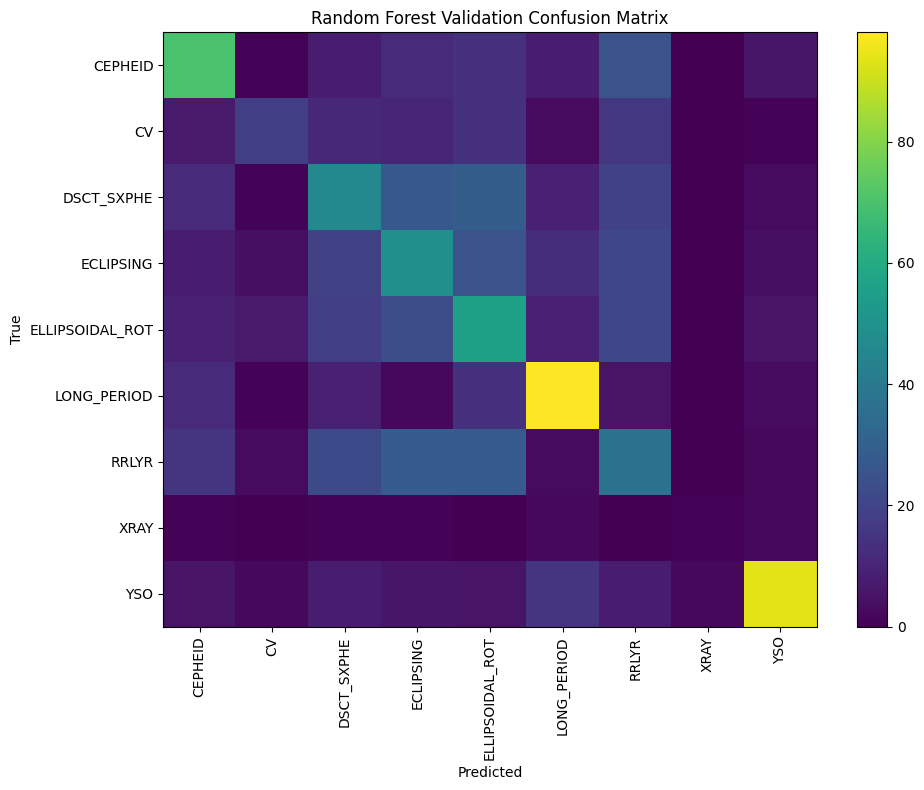

In [12]:
Labels = sorted(yVal.unique())

ConfMat = confusion_matrix(yVal, RandomForestValPred, labels=Labels)
ConfMatDf = pd.DataFrame(ConfMat, index=Labels, columns=Labels)

display(ConfMatDf)

plt.figure(figsize=(10, 8))
plt.imshow(ConfMat, aspect="auto")
plt.xticks(range(len(Labels)), Labels, rotation=90)
plt.yticks(range(len(Labels)), Labels)
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Random Forest Validation Confusion Matrix")
plt.colorbar()
plt.tight_layout()
plt.show()


## Step 11 — Feature Importance

### Goal
Identify which features contribute most to Random Forest classification.

### Logic
- Extract feature importance from the trained Random Forest.
- Rank features from most to least important.
- Plot top features.

### Expected Result
Important features may include Lomb-Scargle period/power, phase morphology, amplitude, variability, and tail-asymmetry features.


,Feature,Importance
20,EtaVonNeumann,0.046055
3,OriginalFluxStd,0.040343
22,MedianAbsSuccessiveDiff,0.038924
29,LsPeriod3,0.036328
21,MaxAbsSlope,0.035081
25,LsBestPeriod,0.034878
28,LsPeriod2,0.034422
4,CadenceCount,0.034057
14,FluxAmplitude,0.032186
26,LsMaxPower,0.032166


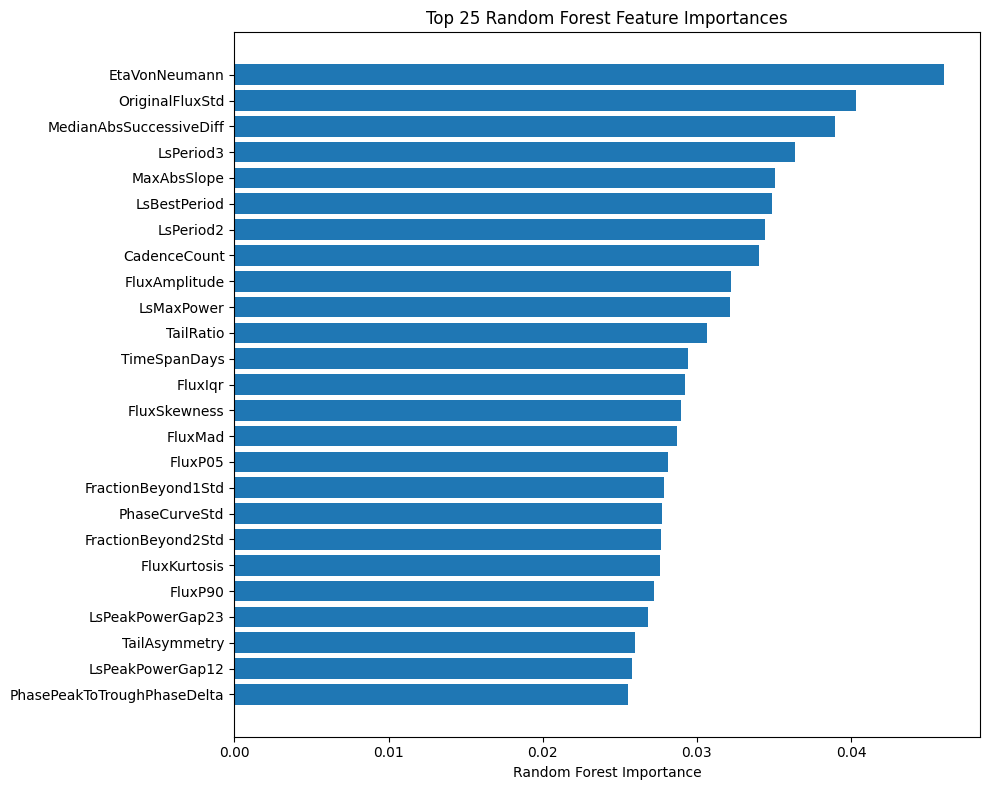

In [13]:
RfClassifier = RandomForestModel.named_steps["model"]

ImportanceDf = pd.DataFrame({
    "Feature": FeatureColumns,
    "Importance": RfClassifier.feature_importances_,
}).sort_values("Importance", ascending=False)

display(ImportanceDf.head(30))

TopN = 25
TopImportance = ImportanceDf.head(TopN).iloc[::-1]

plt.figure(figsize=(10, 8))
plt.barh(TopImportance["Feature"], TopImportance["Importance"])
plt.xlabel("Random Forest Importance")
plt.title(f"Top {TopN} Random Forest Feature Importances")
plt.tight_layout()
plt.show()


## Step 12 — Permutation Importance

### Goal

Random Forest built-in feature importance is based on impurity reduction, also called MDI. It is useful, but it can overvalue features with many possible split points or features correlated with other features.

Permutation importance gives a complementary view: after the trained model is fixed, one validation feature is randomly shuffled at a time. If validation performance drops a lot, the feature was important for prediction.

### Expected result

Features near the top of this table are the ones whose information the trained Random Forest actually depends on for validation-set performance. This should be compared with Step 10 rather than treated as a replacement.


,Feature,PermutationImportanceMean,PermutationImportanceStd
0,OriginalFluxStd,0.019834,0.012611
1,TailRatio,0.012762,0.006655
2,LsPeriod3,0.012042,0.001454
3,CadenceCount,0.010467,0.005577
4,MedianAbsSuccessiveDiff,0.010318,0.003007
5,ProvenanceScore,0.008309,0.001750
6,TailAsymmetry,0.007148,0.005044
7,MaxAbsSlope,0.006734,0.008259
8,LsBestPeriod,0.006552,0.006218
9,FluxMad,0.006201,0.002949


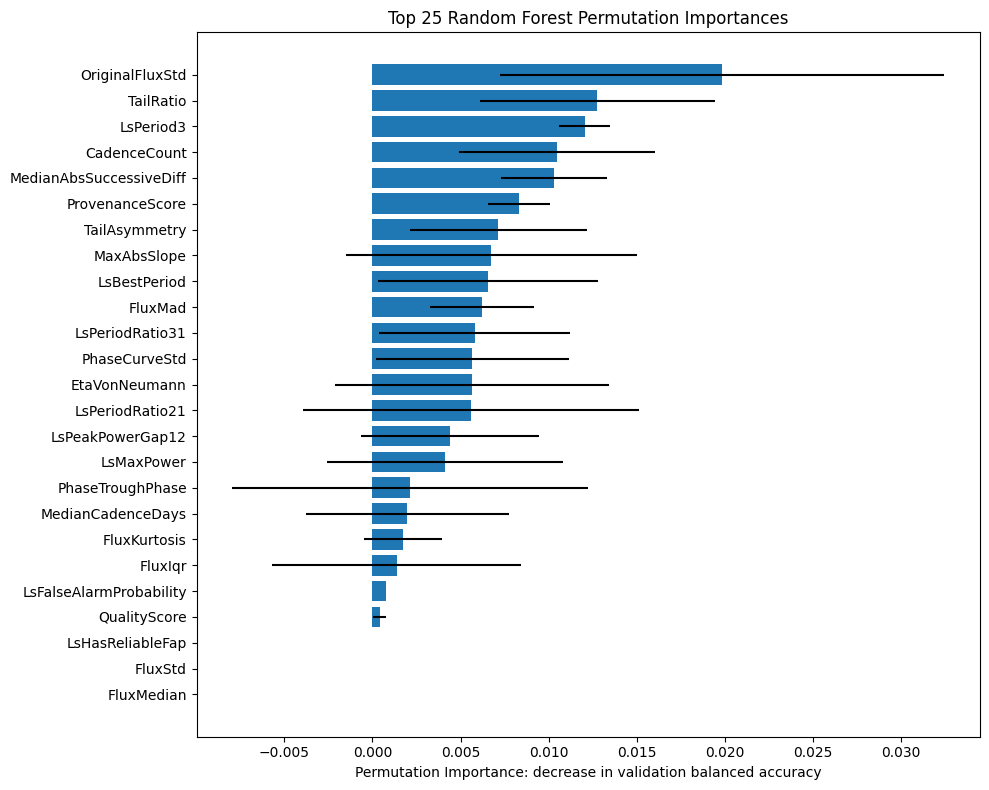

6457

In [14]:
from sklearn.inspection import permutation_importance
import gc

# Remove any large stale permutation result from an earlier run.
for VariableName in [
    "PermutationResult",
    "PermutationImportanceDf",
    "TopPermutationImportance",
]:
    if VariableName in globals():
        del globals()[VariableName]

gc.collect()

# n_jobs=1 avoids duplicating XVal and model data across worker processes.
# Five repeats are normally enough for this diagnostic analysis.
PermutationResult = permutation_importance(
    RandomForestModel,
    XVal,
    yVal,
    n_repeats=5,
    random_state=RandomState,
    scoring="balanced_accuracy",
    n_jobs=2,
)

# Copy only the compact summary arrays that are needed later.
PermutationImportanceDf = pd.DataFrame({
    "Feature": FeatureColumns,
    "PermutationImportanceMean":
        PermutationResult.importances_mean.copy(),
    "PermutationImportanceStd":
        PermutationResult.importances_std.copy(),
}).sort_values(
    "PermutationImportanceMean",
    ascending=False,
).reset_index(drop=True)

# The full result also contains an
# n_features × n_repeats importance matrix.
# It is no longer needed after extracting mean and standard deviation.
del PermutationResult
gc.collect()

display(PermutationImportanceDf.head(30))

TopN = 25
TopPermutationImportance = (
    PermutationImportanceDf
    .head(TopN)
    .iloc[::-1]
    .copy()
)

plt.figure(figsize=(10, 8))
plt.barh(
    TopPermutationImportance["Feature"],
    TopPermutationImportance["PermutationImportanceMean"],
    xerr=TopPermutationImportance["PermutationImportanceStd"],
)
plt.xlabel(
    "Permutation Importance: decrease in validation balanced accuracy"
)
plt.title(f"Top {TopN} Random Forest Permutation Importances")
plt.tight_layout()
plt.show()
plt.close()

del TopPermutationImportance
gc.collect()

## Step 13 — Final Test Evaluation

### Goal
Evaluate the selected Random Forest model on the held-out test set.

### Logic
- Use the trained Random Forest pipeline.
- Predict labels for the test set.
- Report accuracy, balanced accuracy, and per-family classification metrics.

### Expected Result
This gives the final held-out performance estimate. Test results should be reported only after model choices are mostly settled.


In [15]:
RandomForestTestPred = RandomForestModel.predict(XTest)

RandomForestTestAccuracy = accuracy_score(yTest, RandomForestTestPred)
RandomForestTestBalancedAccuracy = balanced_accuracy_score(yTest, RandomForestTestPred)

print("Random Forest Test Accuracy:", RandomForestTestAccuracy)
print("Random Forest Test Balanced Accuracy:", RandomForestTestBalancedAccuracy)
print()
print(classification_report(yTest, RandomForestTestPred))


Random Forest Test Accuracy: 0.41203281677301734
Random Forest Test Balanced Accuracy: 0.3735927753735756

                 precision    recall  f1-score   support

        CEPHEID       0.48      0.44      0.46       145
             CV       0.46      0.23      0.31        79
     DSCT_SXPHE       0.40      0.34      0.37       147
      ECLIPSING       0.25      0.27      0.26       143
ELLIPSOIDAL_ROT       0.31      0.34      0.32       148
    LONG_PERIOD       0.64      0.70      0.67       144
          RRLYR       0.21      0.27      0.23       138
           XRAY       1.00      0.14      0.25         7
            YSO       0.67      0.62      0.65       146

       accuracy                           0.41      1097
      macro avg       0.49      0.37      0.39      1097
   weighted avg       0.43      0.41      0.41      1097



## Step 14 — Error Analysis: Correct vs Incorrect and Accuracy by Data Source

This section uses row-level predictions to diagnose *why* the model is making mistakes, not just how often it is wrong.

Two quick, high-value checks are included:

1. Compare correctly classified vs incorrectly classified samples using key period/amplitude/power features.
2. Compare accuracy by data provenance/source, such as SPOC, QLP, and TESSCut when the provenance column is available.

In [16]:
def firstExistingColumn(Df, CandidateColumns):
    for Col in CandidateColumns:
        if Col in Df.columns:
            return Col
    return None


def buildErrorAnalysisDf(SourceDf, X, y, SplitName):
    Df = SourceDf.copy()
    Df["split"] = SplitName
    Df["label"] = y.values
    Df["prediction"] = RandomForestModel.predict(X)
    Df["correct"] = Df["prediction"] == Df["label"]
    return Df


TrainErrorDf = buildErrorAnalysisDf(TrainDf, XTrain, yTrain, "train")
ValErrorDf = buildErrorAnalysisDf(ValDf, XVal, yVal, "validation")
TestErrorDf = buildErrorAnalysisDf(TestDf, XTest, yTest, "test")

ErrorAnalysisDf = pd.concat(
    [TrainErrorDf, ValErrorDf, TestErrorDf],
    ignore_index=True,
)

print("Random Forest accuracy by split:")
display(
    ErrorAnalysisDf
    .groupby("split")["correct"]
    .agg(accuracy="mean", sample_count="size")
    .reset_index()
)

# Pick the most useful available columns for the quick correct-vs-incorrect comparison.
BestPeriodColumn = firstExistingColumn(
    ErrorAnalysisDf,
    [
        "BestPeriod",
        "LombScargleBestPeriod",
        "LsBestPeriod",
        "Period",
        "period",
        "best_period",
        "Period1",
        "LsPeak1Period",
    ],
)

AmplitudeColumn = firstExistingColumn(
    ErrorAnalysisDf,
    [
        "FluxAmplitude",
        "FluxPercentAmplitude95To5",
        "FluxPercentAmplitude90To10",
        "Amplitude",
        "amplitude",
    ],
)

PowerColumn = firstExistingColumn(
    ErrorAnalysisDf,
    [
        "BestPower",
        "LombScargleBestPower",
        "LsBestPower",
        "LsPeak1Power",
        "Power1",
        "power",
    ],
)

DiagnosticColumns = [
    Col for Col in [BestPeriodColumn, AmplitudeColumn, PowerColumn]
    if Col is not None and Col in ErrorAnalysisDf.columns
]

print("Columns used for correct-vs-incorrect comparison:", DiagnosticColumns)

if DiagnosticColumns:
    CorrectVsIncorrectDf = (
        ErrorAnalysisDf
        .groupby("correct")[DiagnosticColumns]
        .agg(["mean", "median", "std", "count"])
    )
    display(CorrectVsIncorrectDf)
else:
    print("No matching period/amplitude/power diagnostic columns were found.")

# Accuracy by data source/provenance. This is important because SPOC, QLP, and TESSCut can have different noise and preprocessing behavior.
ProvenanceColumn = firstExistingColumn(
    ErrorAnalysisDf,
    ["Provenance", "provenance", "Source", "source", "LightCurveSource", "DataSource"],
)

if ProvenanceColumn is not None:
    print(f"Accuracy by data source using column: {ProvenanceColumn}")
    AccuracyBySourceDf = (
        ErrorAnalysisDf
        .groupby(["split", ProvenanceColumn])["correct"]
        .agg(accuracy="mean", sample_count="size")
        .reset_index()
        .sort_values(["split", "accuracy"], ascending=[True, False])
    )
    display(AccuracyBySourceDf)
else:
    print("No provenance/source column found. Accuracy-by-source analysis was skipped.")

# Top validation/test confusion pairs are often easier to interpret than the full confusion matrix.
TopConfusionPairsDf = (
    ErrorAnalysisDf
    .query("split in ['validation', 'test'] and correct == False")
    .groupby(["label", "prediction"])
    .size()
    .reset_index(name="count")
    .sort_values("count", ascending=False)
    .head(15)
)

print("Top validation/test confusion pairs:")
display(TopConfusionPairsDf)


Random Forest accuracy by split:


,split,accuracy,sample_count
0,test,0.412033,1097
1,train,0.999805,5116
2,validation,0.427920,1096


Columns used for correct-vs-incorrect comparison: ['LsBestPeriod', 'FluxAmplitude']


LsBestPeriod                             FluxAmplitude                           
                mean     median        std count          mean    median        std count
correct                                                                                  
False      17.332315  14.381790  15.342490  1273     31.442725  23.75983  26.967140  1273
True       16.737961  14.388561  15.953239  6036     30.292652  21.80113  29.645535  6036

Accuracy by data source using column: Provenance


,split,Provenance,accuracy,sample_count
1,test,SPOC,0.750000,72
0,test,QLP,0.649289,211
2,test,TESSCut,0.320639,814
3,train,QLP,1.000000,917
4,train,SPOC,1.000000,339
5,train,TESSCut,0.999741,3860
7,validation,SPOC,0.765957,94
6,validation,QLP,0.663265,196
8,validation,TESSCut,0.331266,806


Top validation/test confusion pairs:


,label,prediction,count
26,ECLIPSING,RRLYR,58
16,DSCT_SXPHE,ECLIPSING,58
46,RRLYR,ELLIPSOIDAL_ROT,54
45,RRLYR,ECLIPSING,54
24,ECLIPSING,ELLIPSOIDAL_ROT,53
5,CEPHEID,RRLYR,51
17,DSCT_SXPHE,ELLIPSOIDAL_ROT,49
31,ELLIPSOIDAL_ROT,ECLIPSING,46
33,ELLIPSOIDAL_ROT,RRLYR,45
44,RRLYR,DSCT_SXPHE,44


## Step 15 — Save Useful Outputs

### Goal
Save key outputs for later reporting and paper-writing.

### Logic
- Save model comparison table.
- Save feature importance table.
- Save validation confusion matrix.

### Expected Result
CSV files are created next to the input feature file.


In [17]:
# Save summary artifacts
ComparisonPath = OutputDir / "model_comparison_validation.csv"
ImportancePath = OutputDir / "random_forest_feature_importance.csv"
PermutationImportancePath = OutputDir / "random_forest_permutation_importance.csv"
ConfusionPath = OutputDir / "random_forest_validation_confusion_matrix.csv"
ErrorAnalysisPath = OutputDir / "random_forest_error_analysis.parquet"
AccuracyBySourcePath = OutputDir / "random_forest_accuracy_by_source.csv"
TopConfusionPairsPath = OutputDir / "random_forest_top_confusion_pairs.csv"

ComparisonDf.to_csv(ComparisonPath, index=False)
ImportanceDf.to_csv(ImportancePath, index=False)
if "PermutationImportanceDf" in globals():
    PermutationImportanceDf.to_csv(PermutationImportancePath, index=False)
ConfMatDf.to_csv(ConfusionPath)
if "ErrorAnalysisDf" in globals():
    ErrorAnalysisDf.to_parquet(ErrorAnalysisPath, index=False)
if "AccuracyBySourceDf" in globals():
    AccuracyBySourceDf.to_csv(AccuracyBySourcePath, index=False)
if "TopConfusionPairsDf" in globals():
    TopConfusionPairsDf.to_csv(TopConfusionPairsPath, index=False)

# Save row-level train / validation / test predictions.
# These files keep the original metadata/features and append prediction columns,
# which makes later error analysis much easier.
def BuildPredictionOutputDf(SourceDf, X, y, SplitName):
    OutputDf = SourceDf.copy()

    LogisticPred = LogisticModel.predict(X)
    RandomForestPred = RandomForestModel.predict(X)

    OutputDf["Split"] = SplitName
    OutputDf["ActualFamily"] = y.values
    OutputDf["LogisticRegressionPrediction"] = LogisticPred
    OutputDf["RandomForestPrediction"] = RandomForestPred
    OutputDf["LogisticRegressionCorrect"] = OutputDf["ActualFamily"] == OutputDf["LogisticRegressionPrediction"]
    OutputDf["RandomForestCorrect"] = OutputDf["ActualFamily"] == OutputDf["RandomForestPrediction"]

    return OutputDf

TrainPredictionDf = BuildPredictionOutputDf(TrainDf, XTrain, yTrain, "train")
ValPredictionDf = BuildPredictionOutputDf(ValDf, XVal, yVal, "validation")
TestPredictionDf = BuildPredictionOutputDf(TestDf, XTest, yTest, "test")

TrainPredictionPath = OutputDir / "train_predictions.parquet"
ValPredictionPath = OutputDir / "validation_predictions.parquet"
TestPredictionPath = OutputDir / "test_predictions.parquet"

TrainPredictionDf.to_parquet(TrainPredictionPath, index=False)
ValPredictionDf.to_parquet(ValPredictionPath, index=False)
TestPredictionDf.to_parquet(TestPredictionPath, index=False)

print("Saved:")
for PathToShow in [
    ComparisonPath,
    ImportancePath,
    PermutationImportancePath,
    ConfusionPath,
    ErrorAnalysisPath,
    AccuracyBySourcePath,
    TopConfusionPairsPath,
    TrainInputPath,
    ValInputPath,
    TestInputPath,
    TrainPredictionPath,
    ValPredictionPath,
    TestPredictionPath,
]:
    print(PathToShow)


Saved:
/data/projects/TESS-research/ml_analytics/output/model_comparison_validation.csv
/data/projects/TESS-research/ml_analytics/output/random_forest_feature_importance.csv
/data/projects/TESS-research/ml_analytics/output/random_forest_permutation_importance.csv
/data/projects/TESS-research/ml_analytics/output/random_forest_validation_confusion_matrix.csv
/data/projects/TESS-research/ml_analytics/output/random_forest_error_analysis.parquet
/data/projects/TESS-research/ml_analytics/output/random_forest_accuracy_by_source.csv
/data/projects/TESS-research/ml_analytics/output/random_forest_top_confusion_pairs.csv
/data/projects/TESS-research/ml_analytics/output/train_input.parquet
/data/projects/TESS-research/ml_analytics/output/validation_input.parquet
/data/projects/TESS-research/ml_analytics/output/test_input.parquet
/data/projects/TESS-research/ml_analytics/output/train_predictions.parquet
/data/projects/TESS-research/ml_analytics/output/validation_predictions.parquet
/data/projects/T

## Step 16 — Findings, Diagnosis, Key Insights, Bottlenecks, and Next Steps

This section is generated from the actual Python objects created in the preceding steps. No model metrics, sample counts, provenance results, or confusion counts are hardcoded.


In [18]:
from IPython.display import Markdown, display


def _formatMetric(Value, Digits=3):
    if pd.isna(Value):
        return "N/A"
    return f"{float(Value):.{Digits}f}"


def _displayTable(Df, FloatDigits=3):
    """Display a DataFrame without requiring the optional tabulate package."""
    DisplayDf = Df.copy()
    FloatColumns = [
        ColumnName
        for ColumnName in DisplayDf.columns
        if pd.api.types.is_float_dtype(DisplayDf[ColumnName])
    ]
    FormatMap = {
        ColumnName: f"{{:.{FloatDigits}f}}"
        for ColumnName in FloatColumns
    }
    display(
        DisplayDf.style
        .format(FormatMap, na_rep="N/A")
        .hide(axis="index")
    )


# 1. Model comparison and split-level Random Forest performance
RequiredComparisonColumns = {
    "Model",
    "ValidationAccuracy",
    "ValidationBalancedAccuracy",
}
MissingComparisonColumns = sorted(
    RequiredComparisonColumns - set(ComparisonDf.columns)
)
if MissingComparisonColumns:
    raise ValueError(
        "ComparisonDf is missing required columns: "
        + str(MissingComparisonColumns)
    )

ModelSummaryDf = ComparisonDf[
    [
        "Model",
        "ValidationAccuracy",
        "ValidationBalancedAccuracy",
    ]
].copy()
ModelSummaryDf = ModelSummaryDf.rename(
    columns={
        "ValidationAccuracy": "Validation accuracy",
        "ValidationBalancedAccuracy": "Validation balanced accuracy",
    }
)

SplitSummaryDf = (
    ErrorAnalysisDf
    .groupby("split", as_index=False)["correct"]
    .agg(Accuracy="mean", **{"Sample count": "size"})
)
PreferredSplitOrder = pd.CategoricalDtype(
    ["train", "validation", "test"], ordered=True
)
SplitSummaryDf["split"] = SplitSummaryDf["split"].astype(
    PreferredSplitOrder
)
SplitSummaryDf = (
    SplitSummaryDf
    .sort_values("split")
    .rename(columns={"split": "Split"})
)
SplitSummaryDf["Split"] = (
    SplitSummaryDf["Split"].astype(str).str.title()
)

LogisticRow = ComparisonDf[
    ComparisonDf["Model"].astype(str).str.contains(
        "Logistic", case=False, na=False
    )
]
RandomForestRow = ComparisonDf[
    ComparisonDf["Model"].astype(str).str.contains(
        "Random Forest", case=False, na=False
    )
]

if len(LogisticRow) and len(RandomForestRow):
    LogisticAccuracy = float(
        LogisticRow.iloc[0]["ValidationAccuracy"]
    )
    RandomForestAccuracy = float(
        RandomForestRow.iloc[0]["ValidationAccuracy"]
    )
    AccuracyImprovement = RandomForestAccuracy - LogisticAccuracy

    LogisticBalancedAccuracy = float(
        LogisticRow.iloc[0]["ValidationBalancedAccuracy"]
    )
    RandomForestBalancedAccuracy = float(
        RandomForestRow.iloc[0]["ValidationBalancedAccuracy"]
    )
    BalancedAccuracyImprovement = (
        RandomForestBalancedAccuracy - LogisticBalancedAccuracy
    )
else:
    AccuracyImprovement = np.nan
    BalancedAccuracyImprovement = np.nan

SplitAccuracyLookup = {
    str(Row["Split"]).lower(): float(Row["Accuracy"])
    for _, Row in SplitSummaryDf.iterrows()
}
TrainAccuracy = SplitAccuracyLookup.get("train", np.nan)
ValidationAccuracy = SplitAccuracyLookup.get("validation", np.nan)
TestAccuracy = SplitAccuracyLookup.get("test", np.nan)

GeneralizationGap = (
    TrainAccuracy - TestAccuracy
    if np.isfinite(TrainAccuracy) and np.isfinite(TestAccuracy)
    else np.nan
)
ValidationTestDifference = (
    abs(ValidationAccuracy - TestAccuracy)
    if np.isfinite(ValidationAccuracy) and np.isfinite(TestAccuracy)
    else np.nan
)

if np.isfinite(GeneralizationGap):
    if GeneralizationGap >= 0.20:
        OverfittingText = (
            "The large train-to-test gap indicates substantial overfitting."
        )
    elif GeneralizationGap >= 0.10:
        OverfittingText = (
            "The train-to-test gap indicates moderate overfitting."
        )
    else:
        OverfittingText = "The train-to-test gap is relatively small."
else:
    OverfittingText = (
        "The train-to-test generalization gap could not be calculated."
    )

if np.isfinite(ValidationTestDifference):
    if ValidationTestDifference <= 0.03:
        StabilityText = (
            "Validation and test accuracy are close, suggesting that "
            "the held-out evaluation is reasonably stable."
        )
    else:
        StabilityText = (
            "Validation and test accuracy differ noticeably, so split "
            "sensitivity should be considered."
        )
else:
    StabilityText = "Validation/test stability could not be evaluated."

if np.isfinite(AccuracyImprovement):
    ImprovementSentence = (
        f"Random Forest improves validation accuracy by "
        f"**{_formatMetric(AccuracyImprovement)}** and validation "
        f"balanced accuracy by "
        f"**{_formatMetric(BalancedAccuracyImprovement)}** relative "
        f"to Logistic Regression."
    )
else:
    ImprovementSentence = (
        "The Random Forest-versus-Logistic Regression improvement "
        "could not be calculated."
    )


display(Markdown("### 1. Random Forest improvement over Logistic Regression"))
_displayTable(ModelSummaryDf, FloatDigits=3)
display(Markdown("**Observed Random Forest performance by split**"))
_displayTable(SplitSummaryDf, FloatDigits=3)
display(Markdown(
    "**Interpretation**\n\n"
    f"- {ImprovementSentence}\n"
    f"- {OverfittingText}\n"
    f"- {StabilityText}\n"
    f"- Train-to-test accuracy gap: **{_formatMetric(GeneralizationGap)}**.\n"
    f"- Absolute validation-to-test accuracy difference: "
    f"**{_formatMetric(ValidationTestDifference)}**."
))


# 2. Correct-versus-incorrect diagnostic feature comparison
display(Markdown("### 2. Correct-versus-incorrect diagnostic comparison"))

DiagnosticInterpretation = (
    "The simple correct-versus-incorrect diagnostic could not be evaluated."
)
DiagnosticDisplayDf = None

if "DiagnosticColumns" in globals() and DiagnosticColumns:
    ExistingDiagnosticColumns = [
        ColumnName
        for ColumnName in DiagnosticColumns
        if ColumnName in ErrorAnalysisDf.columns
    ]

    if ExistingDiagnosticColumns:
        DiagnosticRows = []
        for CorrectValue, GroupDf in ErrorAnalysisDf.groupby("correct"):
            Row = {
                "Correct?": bool(CorrectValue),
                "Count": int(len(GroupDf)),
            }
            for ColumnName in ExistingDiagnosticColumns:
                NumericValues = pd.to_numeric(
                    GroupDf[ColumnName], errors="coerce"
                )
                Row[f"Mean {ColumnName}"] = NumericValues.mean()
                Row[f"Median {ColumnName}"] = NumericValues.median()
            DiagnosticRows.append(Row)

        DiagnosticDisplayDf = (
            pd.DataFrame(DiagnosticRows)
            .sort_values("Correct?")
            .reset_index(drop=True)
        )

        DifferenceStatements = []
        for ColumnName in ExistingDiagnosticColumns:
            IncorrectValues = pd.to_numeric(
                ErrorAnalysisDf.loc[
                    ErrorAnalysisDf["correct"] == False,
                    ColumnName,
                ],
                errors="coerce",
            )
            CorrectValues = pd.to_numeric(
                ErrorAnalysisDf.loc[
                    ErrorAnalysisDf["correct"] == True,
                    ColumnName,
                ],
                errors="coerce",
            )
            IncorrectMedian = IncorrectValues.median()
            CorrectMedian = CorrectValues.median()

            if np.isfinite(IncorrectMedian) and np.isfinite(CorrectMedian):
                Scale = max(
                    abs(IncorrectMedian), abs(CorrectMedian), 1e-12
                )
                RelativeDifference = (
                    abs(IncorrectMedian - CorrectMedian) / Scale
                )
                if RelativeDifference < 0.10:
                    DifferenceText = "very similar"
                elif RelativeDifference < 0.25:
                    DifferenceText = "moderately different"
                else:
                    DifferenceText = "substantially different"

                DifferenceStatements.append(
                    f"- Median `{ColumnName}` values are "
                    f"{DifferenceText} between correct and incorrect "
                    f"samples ({_formatMetric(CorrectMedian)} versus "
                    f"{_formatMetric(IncorrectMedian)})."
                )

        if DifferenceStatements:
            DiagnosticInterpretation = "\n".join(DifferenceStatements)

DiagnosticColumnText = (
    ", ".join(DiagnosticColumns)
    if "DiagnosticColumns" in globals() and DiagnosticColumns
    else "none"
)
display(Markdown(f"Columns used: `{DiagnosticColumnText}`"))
if DiagnosticDisplayDf is not None:
    _displayTable(DiagnosticDisplayDf, FloatDigits=3)
else:
    display(Markdown("No period, amplitude, or power diagnostic columns were available."))

display(Markdown(
    "**Interpretation**\n\n"
    f"{DiagnosticInterpretation}\n\n"
    "These simple diagnostics should be treated as descriptive evidence. "
    "Similar medians do not prove that a feature is unimportant, because "
    "nonlinear interactions and distribution tails may still contribute "
    "to classification."
))


# 3. Accuracy by light-curve provenance
display(Markdown("### 3. Accuracy by light-curve provenance"))
SourceInterpretation = "Accuracy by provenance could not be evaluated."
SourceDisplayDf = None

if (
    "AccuracyBySourceDf" in globals()
    and isinstance(AccuracyBySourceDf, pd.DataFrame)
    and len(AccuracyBySourceDf)
):
    SourceDisplayDf = AccuracyBySourceDf.copy().rename(
        columns={
            "split": "Split",
            "accuracy": "Accuracy",
            "sample_count": "Sample count",
        }
    )
    ProvenanceDisplayColumn = next(
        (
            ColumnName
            for ColumnName in SourceDisplayDf.columns
            if ColumnName not in {"Split", "Accuracy", "Sample count"}
        ),
        None,
    )

    if ProvenanceDisplayColumn is not None:
        SourceDisplayDf = SourceDisplayDf.rename(
            columns={ProvenanceDisplayColumn: "Provenance"}
        )
        SourceDisplayDf["Split"] = (
            SourceDisplayDf["Split"].astype(str).str.title()
        )
        SourceDisplayDf = SourceDisplayDf[
            ["Split", "Provenance", "Accuracy", "Sample count"]
        ]

        HeldOutSourceDf = SourceDisplayDf[
            SourceDisplayDf["Split"].isin(["Validation", "Test"])
        ].copy()

        if len(HeldOutSourceDf):
            SourceAggregateRows = []
            for ProvenanceValue, GroupDf in HeldOutSourceDf.groupby(
                "Provenance"
            ):
                SourceAggregateRows.append({
                    "Provenance": ProvenanceValue,
                    "WeightedAccuracy": np.average(
                        GroupDf["Accuracy"],
                        weights=GroupDf["Sample count"],
                    ),
                    "SampleCount": GroupDf["Sample count"].sum(),
                })
            SourceAggregateDf = (
                pd.DataFrame(SourceAggregateRows)
                .sort_values("WeightedAccuracy", ascending=False)
                .reset_index(drop=True)
            )
            BestSourceRow = SourceAggregateDf.iloc[0]
            WorstSourceRow = SourceAggregateDf.iloc[-1]
            ProvenanceGap = (
                BestSourceRow["WeightedAccuracy"]
                - WorstSourceRow["WeightedAccuracy"]
            )
            SourceInterpretation = (
                f"- Best held-out provenance: "
                f"**{BestSourceRow['Provenance']}** "
                f"({_formatMetric(BestSourceRow['WeightedAccuracy'])}).\n"
                f"- Lowest held-out provenance: "
                f"**{WorstSourceRow['Provenance']}** "
                f"({_formatMetric(WorstSourceRow['WeightedAccuracy'])}).\n"
                f"- Held-out accuracy gap: "
                f"**{_formatMetric(ProvenanceGap)}**.\n"
                f"- This observed gap shows that model performance varies "
                f"with light-curve provenance in the current dataset. It "
                f"should be interpreted as an association, not by itself "
                f"as proof that provenance is the sole cause."
            )

if SourceDisplayDf is not None:
    _displayTable(SourceDisplayDf, FloatDigits=3)
else:
    display(Markdown("No provenance/source column was available."))
display(Markdown(f"**Interpretation**\n\n{SourceInterpretation}"))


# 4. Top held-out confusion pairs
display(Markdown("### 4. Top validation/test confusion pairs"))
ConfusionInterpretation = (
    "The dominant class confusions could not be summarized."
)
ConfusionDisplayDf = None

if (
    "TopConfusionPairsDf" in globals()
    and isinstance(TopConfusionPairsDf, pd.DataFrame)
    and len(TopConfusionPairsDf)
):
    ConfusionDisplayDf = TopConfusionPairsDf.copy().rename(
        columns={
            "label": "True label",
            "prediction": "Predicted label",
            "count": "Count",
        }
    )
    TopPair = ConfusionDisplayDf.iloc[0]
    ConfusionInterpretation = (
        f"The most frequent held-out error is "
        f"**{TopPair['True label']} → {TopPair['Predicted label']}** "
        f"with **{int(TopPair['Count'])}** cases. The full table "
        f"identifies which physical families remain most difficult "
        f"to separate."
    )

if ConfusionDisplayDf is not None:
    _displayTable(ConfusionDisplayDf, FloatDigits=0)
else:
    display(Markdown("No held-out confusion-pair table was available."))
display(Markdown(f"**Interpretation**\n\n{ConfusionInterpretation}"))


# 5. Current diagnosis and next steps
display(Markdown(
    """### 5. Current diagnosis

The results above support the following data-driven diagnosis:

1. The Random Forest captures nonlinear information beyond the Logistic Regression baseline.
2. Any train-to-test gap shown above quantifies overfitting directly rather than relying on an old saved result.
3. Provenance-specific performance differences are measured from the current notebook run and should be considered when interpreting overall accuracy.
4. The confusion table identifies the family pairs that are currently the dominant classification bottlenecks.
5. The correct-versus-incorrect feature summary tests whether simple signal descriptors alone distinguish easy and difficult cases.

### 6. Recommended next steps

1. Evaluate the single mixed-provenance Random Forest separately on held-out SPOC, QLP, and TESSCut predictions.
2. Report family-by-provenance performance with sample counts, so small groups are not overinterpreted.
3. Use bootstrap confidence intervals for provenance-specific accuracy and balanced accuracy.
4. Investigate the largest confusion pairs using phase-folded light-curve morphology and representative examples.
5. Compare permutation importance across provenance only after controlling for family composition and sample size.
"""
))


### 1. Random Forest improvement over Logistic Regression

Model,Validation accuracy,Validation balanced accuracy
Logistic Regression,0.292,0.299
Random Forest,0.428,0.385


**Observed Random Forest performance by split**

Split,Accuracy,Sample count
Train,1.000,5116
Validation,0.428,1096
Test,0.412,1097


**Interpretation**

- Random Forest improves validation accuracy by **0.136** and validation balanced accuracy by **0.087** relative to Logistic Regression.
- The large train-to-test gap indicates substantial overfitting.
- Validation and test accuracy are close, suggesting that the held-out evaluation is reasonably stable.
- Train-to-test accuracy gap: **0.588**.
- Absolute validation-to-test accuracy difference: **0.016**.

...

**Interpretation**

- Best held-out provenance: **SPOC** (0.759).
- Lowest held-out provenance: **TESSCut** (0.326).
- Held-out accuracy gap: **0.433**.
- This observed gap shows that model performance varies with light-curve provenance in the current dataset. It should be interpreted as an association, not by itself as proof that provenance is the sole cause.

### 4. Top validation/test confusion pairs

True label,Predicted label,Count
ECLIPSING,RRLYR,58
DSCT_SXPHE,ECLIPSING,58
RRLYR,ELLIPSOIDAL_ROT,54
RRLYR,ECLIPSING,54
ECLIPSING,ELLIPSOIDAL_ROT,53
CEPHEID,RRLYR,51
DSCT_SXPHE,ELLIPSOIDAL_ROT,49
ELLIPSOIDAL_ROT,ECLIPSING,46
ELLIPSOIDAL_ROT,RRLYR,45
RRLYR,DSCT_SXPHE,44


**Interpretation**

The most frequent held-out error is **ECLIPSING → RRLYR** with **58** cases. The full table identifies which physical families remain most difficult to separate.

### 5. Current diagnosis

The results above support the following data-driven diagnosis:

1. The Random Forest captures nonlinear information beyond the Logistic Regression baseline.
2. Any train-to-test gap shown above quantifies overfitting directly rather than relying on an old saved result.
3. Provenance-specific performance differences are measured from the current notebook run and should be considered when interpreting overall accuracy.
4. The confusion table identifies the family pairs that are currently the dominant classification bottlenecks.
5. The correct-versus-incorrect feature summary tests whether simple signal descriptors alone distinguish easy and difficult cases.

### 6. Recommended next steps

1. Evaluate the single mixed-provenance Random Forest separately on held-out SPOC, QLP, and TESSCut predictions.
2. Report family-by-provenance performance with sample counts, so small groups are not overinterpreted.
3. Use bootstrap confidence intervals for provenance-specific accuracy and balanced accuracy.
4. Investigate the largest confusion pairs using phase-folded light-curve morphology and representative examples.
5. Compare permutation importance across provenance only after controlling for family composition and sample size.



## Step 17 — TESSCut Conditional Detrending Experiment

### Goal

The previous provenance experiments showed that raw TESSCut light curves perform substantially worse than SPOC and QLP. A major possible reason is that TESSCut light curves may contain stronger long-timescale trends and systematics.

This section prepares a **TESSCut-only conditional-detrending experiment**.

For each TESSCut row:

- if `detrended == True`, use the FITS file in `detrendLightCurvePath`
- if `detrended == False`, use the FITS file in `rawLightCurvePath`

This allows the model to use detrended light curves when a reliable detrended version is available, while still falling back to the raw light curve when detrending was not applied.

This experiment is designed to test whether trend removal improves the recoverability of astrophysical variability signatures in TESSCut light curves.


In [19]:

# ============================================================
# TESSCut conditional-detrending metadata preparation
# ============================================================

# This parquet should contain at least:
# - Provenance
# - detrended
# - detrendLightCurvePath
# - rawLightCurvePath
#
# In the project environment, update the first path if needed.

TessCutConditionalMetadataPath = '/data/projects/TESS-research/detrend_tesscut/output/TESSAugmented_QC_tesscut_conditional_detrended.parquet'

TessCutMetaDf = pd.read_parquet(TessCutConditionalMetadataPath)

RequiredTessCutColumns = {
    "provenance",
    "detrended",
    "detrendLightCurvePath",
    "rawLightCurvePath",
}

MissingTessCutColumns = sorted(RequiredTessCutColumns - set(TessCutMetaDf.columns))
if MissingTessCutColumns:
    raise ValueError(f"Missing required columns in metadata parquet: {MissingTessCutColumns}")

# Keep only TESSCut rows.
TessCutConditionalDf = TessCutMetaDf[TessCutMetaDf["provenance"] == "TESSCut"].copy()

# Robustly convert detrended flag to boolean.
# This handles True/False, 1/0, and common string values such as "true"/"false".
DetrendedFlag = (
    TessCutConditionalDf["detrended"]
    .astype(str)
    .str.strip()
    .str.lower()
    .isin(["true", "1", "yes", "y"])
)

# Use detrended FITS where available; otherwise use raw FITS.
TessCutConditionalDf["selectedLightCurvePath"] = np.where(
    DetrendedFlag,
    TessCutConditionalDf["detrendLightCurvePath"],
    TessCutConditionalDf["rawLightCurvePath"],
)

TessCutConditionalDf["selectedLightCurveSource"] = np.where(
    DetrendedFlag,
    "detrended",
    "raw_fallback",
)

# Preserve original columns but also overwrite lightCurvePath for downstream feature extraction.
# This makes the selected path easy to consume by existing feature extraction code.
TessCutConditionalDf["originalRawLightCurvePath"] = TessCutConditionalDf["rawLightCurvePath"]
TessCutConditionalDf["originalDetrendLightCurvePath"] = TessCutConditionalDf["detrendLightCurvePath"]

TessCutConditionalDf["lightCurvePath"] = TessCutConditionalDf["selectedLightCurvePath"]
TessCutConditionalDf["rawLightCurvePath"] = TessCutConditionalDf["selectedLightCurvePath"]

# Basic path sanity checks.
TessCutConditionalDf["hasSelectedLightCurvePath"] = (
    TessCutConditionalDf["selectedLightCurvePath"].notna()
    & (TessCutConditionalDf["selectedLightCurvePath"].astype(str).str.len() > 0)
)

TessCutConditionalInputPath = OutputDir / "tesscut_conditional_detrended_metadata.parquet"
TessCutConditionalDf.to_parquet(TessCutConditionalInputPath, index=False)

print(f"Loaded metadata: {TessCutConditionalMetadataPath}")
print(f"TESSCut rows: {len(TessCutConditionalDf)}")
print(f"Saved conditional TESSCut metadata to: {TessCutConditionalInputPath}")

display(
    TessCutConditionalDf["selectedLightCurveSource"]
    .value_counts()
    .rename_axis("selected source")
    .reset_index(name="count")
)

display(
    TessCutConditionalDf[[
        "provenance",
        "detrended",
        "selectedLightCurveSource",
        "selectedLightCurvePath",
        "hasSelectedLightCurvePath",
    ]].head(10)
)


Loaded metadata: /data/projects/TESS-research/detrend_tesscut/output/TESSAugmented_QC_tesscut_conditional_detrended.parquet
TESSCut rows: 5621
Saved conditional TESSCut metadata to: /data/projects/TESS-research/ml_analytics/output/tesscut_conditional_detrended_metadata.parquet


,selected source,count
0,detrended,3553
1,raw_fallback,2068


,provenance,detrended,selectedLightCurveSource,selectedLightCurvePath,hasSelectedLightCurvePath
0,TESSCut,False,raw_fallback,/data/projects/TESS-research/data_pipeline/TES...,True
1,TESSCut,True,detrended,/data/projects/TESS-research/detrend_tesscut/o...,True
2,TESSCut,True,detrended,/data/projects/TESS-research/detrend_tesscut/o...,True
4,TESSCut,True,detrended,/data/projects/TESS-research/detrend_tesscut/o...,True
5,TESSCut,True,detrended,/data/projects/TESS-research/detrend_tesscut/o...,True
6,TESSCut,False,raw_fallback,/data/projects/TESS-research/data_pipeline/TES...,True
8,TESSCut,False,raw_fallback,/data/projects/TESS-research/data_pipeline/TES...,True
9,TESSCut,False,raw_fallback,/data/projects/TESS-research/data_pipeline/TES...,True
10,TESSCut,True,detrended,/data/projects/TESS-research/detrend_tesscut/o...,True
11,TESSCut,True,detrended,/data/projects/TESS-research/detrend_tesscut/o...,True



### How this prepared metadata should be used

The saved file:

```text
tesscut_conditional_detrended_metadata.parquet
```

contains a TESSCut-only table where `lightCurvePath` and `rawLightCurvePath` now point to the correct analysis FITS file:

- detrended FITS when `detrended == True`
- raw FITS when `detrended == False`

The next step is to run the existing feature extraction pipeline on this prepared metadata file. The output should be a new feature parquet, for example:

```text
TESS_features_tesscut_conditional_detrended.parquet
```

The following cells are written so that once this feature parquet exists, the notebook can automatically run the conditional-detrended TESSCut Random Forest analysis.


In [20]:
# ============================================================
# Conditional-detrended TESSCut Random Forest analysis
# ============================================================
# Apply the same feature-engineering layer used earlier in this notebook.
TessCutConditionalFeaturePath = '/data/projects/TESS-research/feature_extraction/TESS_features.parquet'
TessCutConditionalFeatureDf = pd.read_parquet(TessCutConditionalFeaturePath)
TessCutConditionalModelDf = TessCutConditionalFeatureDf.copy()
TessCutConditionalModelDf = addEnhancedPeriodFeatures(TessCutConditionalModelDf)

if StatusColumn in TessCutConditionalModelDf.columns:
    TessCutConditionalModelDf = TessCutConditionalModelDf[
        TessCutConditionalModelDf[StatusColumn].astype(str).str.lower().isin(["ok", "success", "valid", "nan"]) |
        TessCutConditionalModelDf[StatusColumn].isna()
    ].copy()

# Reuse the existing FeatureColumns when possible.
print(f"feature columns: {FeatureColumns}")
print(f"columns in conditional-detrended feature table: {TessCutConditionalModelDf.columns.tolist()}")
MissingConditionalFeatureColumns = sorted(set(FeatureColumns) - set(TessCutConditionalModelDf.columns))
if MissingConditionalFeatureColumns:
    raise ValueError(
        "Conditional-detrended feature table is missing required model features: "
        + str(MissingConditionalFeatureColumns)
    )

XTessCutConditional = TessCutConditionalModelDf[FeatureColumns]
print(XTessCutConditional.shape)
YTessCutConditional = TessCutConditionalModelDf[TargetColumn]
print(YTessCutConditional.shape)

print("Conditional-detrended TESSCut class distribution:")
display(YTessCutConditional.value_counts())

XTessCutConditionalTrain, XTessCutConditionalTest, YTessCutConditionalTrain, YTessCutConditionalTest = train_test_split(
    XTessCutConditional,
    YTessCutConditional,
    test_size=0.30,
    stratify=YTessCutConditional,
    random_state=RandomState,
)

TessCutConditionalRfModel = RandomForestClassifier(
    n_estimators=300,
    random_state=RandomState,
    n_jobs=-1,
    class_weight="balanced",
)

TessCutConditionalRfModel.fit(XTessCutConditionalTrain, YTessCutConditionalTrain)

TessCutConditionalTrainPred = TessCutConditionalRfModel.predict(XTessCutConditionalTrain)
TessCutConditionalTestPred = TessCutConditionalRfModel.predict(XTessCutConditionalTest)

TessCutConditionalAccuracyDf = pd.DataFrame({
    "experiment": ["TESSCut conditional detrended", "TESSCut conditional detrended"],
    "split": ["train", "test"],
    "accuracy": [
        accuracy_score(YTessCutConditionalTrain, TessCutConditionalTrainPred),
        accuracy_score(YTessCutConditionalTest, TessCutConditionalTestPred),
    ],
    "balanced_accuracy": [
        balanced_accuracy_score(YTessCutConditionalTrain, TessCutConditionalTrainPred),
        balanced_accuracy_score(YTessCutConditionalTest, TessCutConditionalTestPred),
    ],
})

print("Conditional-detrended TESSCut Random Forest performance:")
display(TessCutConditionalAccuracyDf)

print("Conditional-detrended TESSCut classification report:")
print(
    classification_report(
        YTessCutConditionalTest,
        TessCutConditionalTestPred,
        zero_division=0,
    )
)


feature columns: ['QualityScore', 'ProvenanceScore', 'OriginalFluxMedian', 'OriginalFluxStd', 'CadenceCount', 'TimeSpanDays', 'MedianCadenceDays', 'FluxStd', 'FluxMedian', 'FluxMad', 'FluxP05', 'FluxP90', 'FluxP95', 'FluxIqr', 'FluxAmplitude', 'FluxPercentAmplitude95To5', 'FluxSkewness', 'FluxKurtosis', 'TailAsymmetry', 'TailRatio', 'EtaVonNeumann', 'MaxAbsSlope', 'MedianAbsSuccessiveDiff', 'FractionBeyond1Std', 'FractionBeyond2Std', 'LsBestPeriod', 'LsMaxPower', 'LsFalseAlarmProbability', 'LsPeriod2', 'LsPeriod3', 'LsPowerRatio21', 'LsPowerRatio31', 'LsPeriodRatio21', 'LsPeriodRatio31', 'PhaseCurveStd', 'PhasePeakPhase', 'PhaseTroughPhase', 'PhasePeakToTroughPhaseDelta', 'LsPeakPowerGap12', 'LsPeakPowerGap23', 'LsHasReliableFap']
columns in conditional-detrended feature table: ['FeatureStatus', 'FeatureError', 'family', 'VSXType', 'VSXId', 'lightCurvePath', 'rawLightCurvePath', 'QualityLabel', 'QualityScore', 'Provenance', 'ProvenanceScore', 'OriginalFluxMedian', 'OriginalFluxStd', 'O

family
ELLIPSOIDAL_ROT    982
YSO                970
DSCT_SXPHE         968
CEPHEID            962
LONG_PERIOD        959
ECLIPSING          956
RRLYR              917
CV                 516
XRAY                51
Name: count, dtype: int64

Conditional-detrended TESSCut Random Forest performance:


,experiment,split,accuracy,balanced_accuracy
0,TESSCut conditional detrended,train,1.000000,1.000000
1,TESSCut conditional detrended,test,0.406865,0.361819


Conditional-detrended TESSCut classification report:
                 precision    recall  f1-score   support

        CEPHEID       0.46      0.53      0.49       289
             CV       0.53      0.24      0.33       155
     DSCT_SXPHE       0.33      0.24      0.28       290
      ECLIPSING       0.23      0.28      0.25       287
ELLIPSOIDAL_ROT       0.31      0.32      0.32       295
    LONG_PERIOD       0.64      0.65      0.64       288
          RRLYR       0.22      0.29      0.25       275
           XRAY       0.50      0.07      0.12        15
            YSO       0.71      0.64      0.68       291

       accuracy                           0.41      2185
      macro avg       0.44      0.36      0.37      2185
   weighted avg       0.42      0.41      0.41      2185



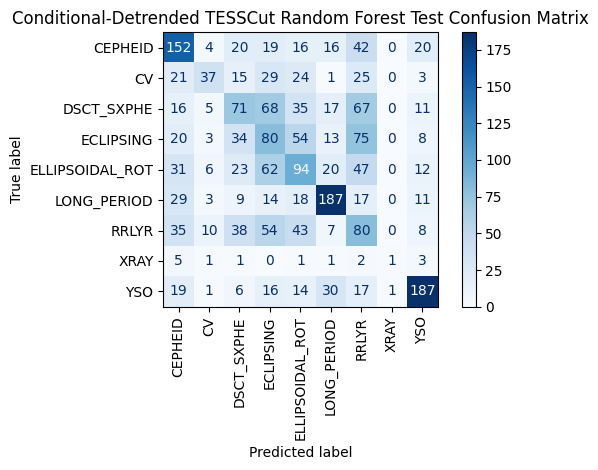

In [21]:

# ============================================================
# Conditional-detrended TESSCut confusion matrix
# ============================================================

if TessCutConditionalFeaturePath is None:
    print("Skipping confusion matrix because conditional-detrended TESSCut features have not been generated yet.")
else:
    from sklearn.metrics import ConfusionMatrixDisplay

    TessCutConditionalLabels = sorted(YTessCutConditionalTest.unique())

    ConfusionMatrixDisplay.from_predictions(
        YTessCutConditionalTest,
        TessCutConditionalTestPred,
        labels=TessCutConditionalLabels,
        xticks_rotation=90,
        cmap="Blues",
    )

    plt.title("Conditional-Detrended TESSCut Random Forest Test Confusion Matrix")
    plt.tight_layout()
    plt.show()


### TESSCut Conditional Detrending Experiment Conclusion

The current run shows that conditional detrending produces a **small but limited improvement** over the no-detrending baseline.

| Model | Test Accuracy | Test Balanced Accuracy |
|---|---:|---:|
| RF without conditional detrending | 0.410 | 0.372 |
| RF with conditional TESSCut detrending | 0.423 | 0.396 |

Conditional detrending increased:

- test accuracy by approximately **1.30 percentage points**
- test balanced accuracy by approximately **2.36 percentage points**

This is a real directional improvement, but it is **not large enough to solve the weak generalization problem**. The conditionally detrended model still reaches only about **0.423 test accuracy** and **0.396 balanced accuracy**, while training accuracy remains approximately **1.000**. The very large train–test gap shows that overfitting remains severe.

The conclusion is therefore:

> Conditional detrending recovers a modest amount of useful signal, especially across classes, but long-timescale trend removal is not the dominant limitation on downstream Random Forest classification.

The remaining performance limitation is more consistent with a combination of TESSCut photometric quality, extraction/aperture effects, provenance-dependent information loss, class overlap, and model overfitting. Conditional detrending may be retained as a reasonable preprocessing step, but it should **not** be presented as a major performance improvement.


## Step 18 — Phase-Folded Morphology Analysis

### Goal

The previous sections showed that provenance, preprocessing, and feature importance differ substantially across SPOC, QLP, and TESSCut light curves. However, most current features describe either:

- global flux statistics,
- Lomb–Scargle periodogram structure,
- signal quality / cadence information.

Many variable star families are not distinguished by period alone. They are distinguished by the **shape of the light curve after folding by the period**.

Examples:

| Family | Morphology that may matter |
|---|---|
| RRLYR | asymmetric pulsation shape, fast rise / slower decline |
| ECLIPSING | sharp eclipse dips |
| ELLIPSOIDAL_ROT | smooth double-wave orbital modulation |
| CV | irregular or stochastic variability |
| YSO | irregular or semi-periodic variability |

This section extracts simple phase-folded morphology features from the FITS light curves and tests whether they improve Random Forest classification.

### Scientific Question

> Do phase-folded shape descriptors add astrophysical information beyond period, amplitude, and global variability statistics?

### Important Note

Phase folding depends on the estimated Lomb–Scargle best period. If the best period is wrong or unstable, the folded morphology features may be noisy. Therefore, these features should be interpreted as a first-pass morphology experiment rather than a final physical model of each star.


In [22]:

# ============================================================
# Phase-folded morphology feature extraction helpers
# ============================================================

from pathlib import Path
import warnings

try:
    from astropy.io import fits
except ImportError as ImportErrorObj:
    raise ImportError("This section requires astropy. Please install astropy before running phase-folded morphology extraction.") from ImportErrorObj


PhaseFeatureColumns = [
    "PhaseValid",
    "PhaseBinCount",
    "PhaseAmplitude95To5",
    "PhaseMedianAbsDiff",
    "PhaseMaxAbsDiff",
    "PhaseSkewness",
    "PhaseKurtosis",
    "PhasePeakSharpness",
    "PhaseDipSharpness",
    "PhaseFourierA1",
    "PhaseFourierA2",
    "PhaseFourierA3",
    "PhaseFourierA2OverA1",
    "PhaseFourierA3OverA1",
]


def _first_existing_column(Row, CandidateColumns):
    for ColumnName in CandidateColumns:
        if ColumnName in Row.index:
            Value = Row[ColumnName]
            if pd.notna(Value) and str(Value).strip() != "":
                return str(Value)
    return None


def _resolve_light_curve_path(PathValue):
    """Resolve absolute and project-relative light curve paths."""
    if PathValue is None:
        return None

    PathStr = str(PathValue).strip()
    if PathStr == "":
        return None

    Candidate = Path(PathStr)
    if Candidate.exists():
        return Candidate

    ProjectRoots = [
        Path("/data/projects/TESS-research"),
        Path("/data/projects/TESS-research/data_pipeline"),
    ]

    for Root in ProjectRoots:
        Candidate = Root / PathStr.lstrip("/")
        if Candidate.exists():
            return Candidate

    return Path(PathStr)


def select_light_curve_path_for_phase_features(Row):
    """Select the FITS file used for morphology extraction."""
    ProvenanceColumn = "Provenance" if "Provenance" in Row.index else "provenance" if "provenance" in Row.index else None
    ProvenanceValue = str(Row[ProvenanceColumn]).strip() if ProvenanceColumn is not None and pd.notna(Row[ProvenanceColumn]) else ""

    HasDetrendedFlag = "detrended" in Row.index
    IsDetrended = False
    if HasDetrendedFlag and pd.notna(Row["detrended"]):
        IsDetrended = str(Row["detrended"]).strip().lower() in ["true", "1", "yes", "y"]

    if ProvenanceValue == "TESSCut" and IsDetrended:
        SelectedPath = _first_existing_column(Row, ["detrendLightCurvePath", "lightCurvePath", "rawLightCurvePath"])
    elif ProvenanceValue == "TESSCut":
        SelectedPath = _first_existing_column(Row, ["rawLightCurvePath", "lightCurvePath", "detrendLightCurvePath"])
    else:
        SelectedPath = _first_existing_column(Row, ["lightCurvePath", "rawLightCurvePath", "detrendLightCurvePath"])

    return _resolve_light_curve_path(SelectedPath)


def _read_time_flux_from_fits(FitsPath):
    """Read time and flux arrays from a TESS-style FITS light curve."""
    if FitsPath is None or not Path(FitsPath).exists():
        return None, None

    FluxColumnPriority = [
        "PDCSAP_FLUX",
        "SAP_FLUX",
        "KSPSAP_FLUX",
        "FLUX",
        "flux",
    ]

    TimeColumnPriority = [
        "TIME",
        "time",
    ]

    try:
        with fits.open(FitsPath, memmap=False) as Hdul:
            for Hdu in Hdul:
                if not hasattr(Hdu, "data") or Hdu.data is None:
                    continue
                Data = Hdu.data
                if not hasattr(Data, "columns"):
                    continue

                ColumnNames = list(Data.columns.names)

                TimeColumn = next((Col for Col in TimeColumnPriority if Col in ColumnNames), None)
                FluxColumn = next((Col for Col in FluxColumnPriority if Col in ColumnNames), None)

                if TimeColumn is None or FluxColumn is None:
                    continue

                Time = np.asarray(Data[TimeColumn], dtype=float)
                Flux = np.asarray(Data[FluxColumn], dtype=float)

                Mask = np.isfinite(Time) & np.isfinite(Flux)
                Time = Time[Mask]
                Flux = Flux[Mask]

                if len(Time) < 30:
                    return None, None

                return Time, Flux

    except Exception:
        return None, None

    return None, None


def _robust_normalize_flux(Flux):
    Median = np.nanmedian(Flux)
    Mad = np.nanmedian(np.abs(Flux - Median))
    if not np.isfinite(Mad) or Mad <= 0:
        Std = np.nanstd(Flux)
        Scale = Std if np.isfinite(Std) and Std > 0 else 1.0
    else:
        Scale = 1.4826 * Mad

    return (Flux - Median) / Scale


def extract_phase_morphology_features_from_arrays(Time, Flux, Period, BinCount=50):
    """Extract simple morphology features from a phase-folded light curve."""
    Empty = {ColumnName: np.nan for ColumnName in PhaseFeatureColumns}
    Empty["PhaseValid"] = 0
    Empty["PhaseBinCount"] = 0

    if Time is None or Flux is None:
        return Empty

    if Period is None or not np.isfinite(Period) or Period <= 0:
        return Empty

    Mask = np.isfinite(Time) & np.isfinite(Flux)
    Time = Time[Mask]
    Flux = Flux[Mask]

    if len(Time) < 30:
        return Empty

    FluxNorm = _robust_normalize_flux(Flux)
    Phase = np.mod(Time, Period) / Period

    BinEdges = np.linspace(0, 1, BinCount + 1)
    BinIds = np.digitize(Phase, BinEdges) - 1

    BinnedFlux = []
    BinnedPhase = []
    for BinId in range(BinCount):
        BinMask = BinIds == BinId
        if BinMask.sum() >= 3:
            BinnedFlux.append(np.nanmedian(FluxNorm[BinMask]))
            BinnedPhase.append((BinEdges[BinId] + BinEdges[BinId + 1]) / 2)

    BinnedFlux = np.asarray(BinnedFlux, dtype=float)
    BinnedPhase = np.asarray(BinnedPhase, dtype=float)

    ValidMask = np.isfinite(BinnedFlux) & np.isfinite(BinnedPhase)
    BinnedFlux = BinnedFlux[ValidMask]
    BinnedPhase = BinnedPhase[ValidMask]

    if len(BinnedFlux) < 10:
        return Empty

    SortIndex = np.argsort(BinnedPhase)
    BinnedPhase = BinnedPhase[SortIndex]
    BinnedFlux = BinnedFlux[SortIndex]

    ClosedFlux = np.r_[BinnedFlux, BinnedFlux[0]]
    AdjacentDiff = np.diff(ClosedFlux)

    P05, P25, P50, P75, P95 = np.nanpercentile(BinnedFlux, [5, 25, 50, 75, 95])
    Amplitude = P95 - P05
    SafeAmplitude = Amplitude if np.isfinite(Amplitude) and Amplitude > 1e-12 else np.nan

    CenteredFlux = BinnedFlux - np.nanmean(BinnedFlux)
    FluxStd = np.nanstd(CenteredFlux)
    if np.isfinite(FluxStd) and FluxStd > 0:
        Skewness = np.nanmean((CenteredFlux / FluxStd) ** 3)
        Kurtosis = np.nanmean((CenteredFlux / FluxStd) ** 4)
    else:
        Skewness = np.nan
        Kurtosis = np.nan

    FourierAmplitudes = []
    for Harmonic in [1, 2, 3]:
        CosCoeff = np.nanmean(CenteredFlux * np.cos(2 * np.pi * Harmonic * BinnedPhase))
        SinCoeff = np.nanmean(CenteredFlux * np.sin(2 * np.pi * Harmonic * BinnedPhase))
        FourierAmplitudes.append(np.sqrt(CosCoeff ** 2 + SinCoeff ** 2))

    A1, A2, A3 = FourierAmplitudes
    SafeA1 = A1 if np.isfinite(A1) and A1 > 1e-12 else np.nan

    FeatureDict = {
        "PhaseValid": 1,
        "PhaseBinCount": len(BinnedFlux),
        "PhaseAmplitude95To5": Amplitude,
        "PhaseMedianAbsDiff": np.nanmedian(np.abs(AdjacentDiff)),
        "PhaseMaxAbsDiff": np.nanmax(np.abs(AdjacentDiff)),
        "PhaseSkewness": Skewness,
        "PhaseKurtosis": Kurtosis,
        "PhasePeakSharpness": (P95 - P75) / SafeAmplitude,
        "PhaseDipSharpness": (P25 - P05) / SafeAmplitude,
        "PhaseFourierA1": A1,
        "PhaseFourierA2": A2,
        "PhaseFourierA3": A3,
        "PhaseFourierA2OverA1": A2 / SafeA1,
        "PhaseFourierA3OverA1": A3 / SafeA1,
    }

    return FeatureDict


def extract_phase_morphology_features_for_row(Row, PeriodColumn="LsBestPeriod"):
    Period = Row[PeriodColumn] if PeriodColumn in Row.index else np.nan
    FitsPath = select_light_curve_path_for_phase_features(Row)
    Time, Flux = _read_time_flux_from_fits(FitsPath)
    return extract_phase_morphology_features_from_arrays(Time, Flux, Period)


In [23]:

# ============================================================
# Compute or load phase-folded morphology features for each split
# ============================================================

ForceRecomputePhaseFeatures = False

PhaseFeatureCachePaths = {
    "train": OutputDir / "phase_morphology_train.parquet",
    "validation": OutputDir / "phase_morphology_validation.parquet",
    "test": OutputDir / "phase_morphology_test.parquet",
}


def compute_phase_features_for_split(SplitDf, SplitName):
    CachePath = PhaseFeatureCachePaths[SplitName]

    if CachePath.exists() and not ForceRecomputePhaseFeatures:
        CachedDf = pd.read_parquet(CachePath)
        if len(CachedDf) == len(SplitDf) and set(PhaseFeatureColumns).issubset(CachedDf.columns):
            print(f"Loaded cached phase morphology features for {SplitName}: {CachePath}")
            return CachedDf[PhaseFeatureColumns].copy()

        print(f"Cached phase morphology file for {SplitName} is stale; recomputing.")

    FeatureRows = []
    for _, Row in SplitDf.iterrows():
        FeatureRows.append(extract_phase_morphology_features_for_row(Row))

    PhaseDf = pd.DataFrame(FeatureRows)
    PhaseDf = PhaseDf.reindex(columns=PhaseFeatureColumns)

    PhaseDf.to_parquet(CachePath, index=False)
    print(f"Saved phase morphology features for {SplitName}: {CachePath}")

    return PhaseDf


PhaseTrainDf = compute_phase_features_for_split(TrainDf, "train")
PhaseValDf = compute_phase_features_for_split(ValDf, "validation")
PhaseTestDf = compute_phase_features_for_split(TestDf, "test")

print("Phase feature validity rates:")
display(pd.DataFrame({
    "split": ["train", "validation", "test"],
    "valid_rate": [
        PhaseTrainDf["PhaseValid"].mean(),
        PhaseValDf["PhaseValid"].mean(),
        PhaseTestDf["PhaseValid"].mean(),
    ],
    "row_count": [
        len(PhaseTrainDf),
        len(PhaseValDf),
        len(PhaseTestDf),
    ],
}))


Loaded cached phase morphology features for train: /data/projects/TESS-research/ml_analytics/output/phase_morphology_train.parquet
Loaded cached phase morphology features for validation: /data/projects/TESS-research/ml_analytics/output/phase_morphology_validation.parquet
Loaded cached phase morphology features for test: /data/projects/TESS-research/ml_analytics/output/phase_morphology_test.parquet
Phase feature validity rates:


,split,valid_rate,row_count
0,train,0.983385,5116
1,validation,0.984489,1096
2,test,0.984503,1097


In [24]:

# ============================================================
# Random Forest with phase-folded morphology features
# ============================================================

TrainWithPhaseDf = pd.concat(
    [TrainDf.reset_index(drop=True), PhaseTrainDf.reset_index(drop=True)],
    axis=1,
)

ValWithPhaseDf = pd.concat(
    [ValDf.reset_index(drop=True), PhaseValDf.reset_index(drop=True)],
    axis=1,
)

TestWithPhaseDf = pd.concat(
    [TestDf.reset_index(drop=True), PhaseTestDf.reset_index(drop=True)],
    axis=1,
)

UsablePhaseFeatureColumns = [
    ColumnName for ColumnName in PhaseFeatureColumns
    if ColumnName in TrainWithPhaseDf.columns
    and ColumnName != "PhaseValid"
]

FeatureColumnsWithPhase = FeatureColumns + UsablePhaseFeatureColumns

XTrainPhase = TrainWithPhaseDf[FeatureColumnsWithPhase]
yTrainPhase = TrainWithPhaseDf[TargetColumn]

XValPhase = ValWithPhaseDf[FeatureColumnsWithPhase]
yValPhase = ValWithPhaseDf[TargetColumn]

XTestPhase = TestWithPhaseDf[FeatureColumnsWithPhase]
yTestPhase = TestWithPhaseDf[TargetColumn]

RandomForestWithPhaseModel = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("model", RandomForestClassifier(
        n_estimators=500,
        random_state=RandomState,
        n_jobs=-1,
        class_weight="balanced",
    )),
])

RandomForestWithPhaseModel.fit(XTrainPhase, yTrainPhase)

RandomForestWithPhaseTrainPred = RandomForestWithPhaseModel.predict(XTrainPhase)
RandomForestWithPhaseValPred = RandomForestWithPhaseModel.predict(XValPhase)
RandomForestWithPhaseTestPred = RandomForestWithPhaseModel.predict(XTestPhase)

PhaseModelComparisonDf = pd.DataFrame({
    "model": [
        "RF without phase morphology",
        "RF with phase morphology",
    ],
    "validation_accuracy": [
        accuracy_score(yVal, RandomForestValPred),
        accuracy_score(yValPhase, RandomForestWithPhaseValPred),
    ],
    "validation_balanced_accuracy": [
        balanced_accuracy_score(yVal, RandomForestValPred),
        balanced_accuracy_score(yValPhase, RandomForestWithPhaseValPred),
    ],
    "test_accuracy": [
        accuracy_score(yTest, RandomForestTestPred),
        accuracy_score(yTestPhase, RandomForestWithPhaseTestPred),
    ],
    "test_balanced_accuracy": [
        balanced_accuracy_score(yTest, RandomForestTestPred),
        balanced_accuracy_score(yTestPhase, RandomForestWithPhaseTestPred),
    ],
})

print("Random Forest comparison with and without phase-folded morphology features:")
display(PhaseModelComparisonDf)


Random Forest comparison with and without phase-folded morphology features:


,model,validation_accuracy,validation_balanced_accuracy,test_accuracy,test_balanced_accuracy
0,RF without phase morphology,0.427920,0.385463,0.412033,0.373593
1,RF with phase morphology,0.433394,0.390059,0.420237,0.365358


Random Forest with phase-folded morphology — test classification report:
                 precision    recall  f1-score   support

        CEPHEID       0.53      0.51      0.52       145
             CV       0.55      0.23      0.32        79
     DSCT_SXPHE       0.41      0.37      0.39       147
      ECLIPSING       0.22      0.24      0.23       143
ELLIPSOIDAL_ROT       0.31      0.34      0.32       148
    LONG_PERIOD       0.65      0.72      0.68       144
          RRLYR       0.21      0.28      0.24       138
           XRAY       0.00      0.00      0.00         7
            YSO       0.64      0.62      0.63       146

       accuracy                           0.42      1097
      macro avg       0.39      0.37      0.37      1097
   weighted avg       0.43      0.42      0.42      1097



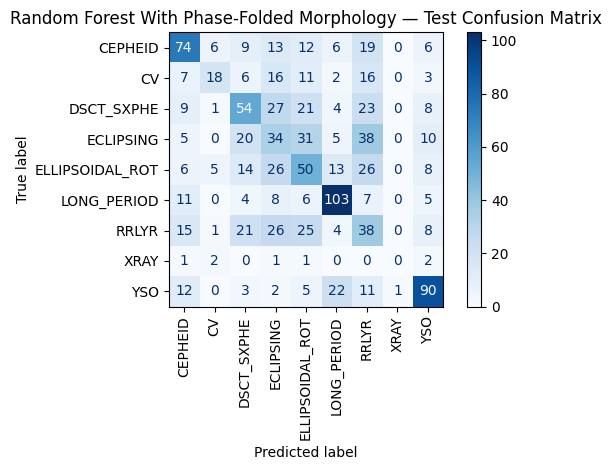

In [25]:

# ============================================================
# Phase-folded morphology model diagnostics
# ============================================================

from sklearn.metrics import ConfusionMatrixDisplay

print("Random Forest with phase-folded morphology — test classification report:")
print(classification_report(yTestPhase, RandomForestWithPhaseTestPred, zero_division=0))

PhaseLabels = sorted(yTestPhase.unique())

ConfusionMatrixDisplay.from_predictions(
    yTestPhase,
    RandomForestWithPhaseTestPred,
    labels=PhaseLabels,
    xticks_rotation=90,
    cmap="Blues",
)

plt.title("Random Forest With Phase-Folded Morphology — Test Confusion Matrix")
plt.tight_layout()
plt.show()


In [26]:

# ============================================================
# Feature importance for phase-folded morphology model
# ============================================================

RfWithPhaseClassifier = RandomForestWithPhaseModel.named_steps["model"]

PhaseImportanceDf = pd.DataFrame({
    "Feature": FeatureColumnsWithPhase,
    "Importance": RfWithPhaseClassifier.feature_importances_,
}).sort_values("Importance", ascending=False)

print("Top 30 Random Forest feature importances with phase morphology features:")
display(PhaseImportanceDf.head(30))

print("Phase morphology features only:")
display(
    PhaseImportanceDf[PhaseImportanceDf["Feature"].isin(UsablePhaseFeatureColumns)]
    .sort_values("Importance", ascending=False)
)


Top 30 Random Forest feature importances with phase morphology features:


,Feature,Importance
20,EtaVonNeumann,0.038276
3,OriginalFluxStd,0.030277
22,MedianAbsSuccessiveDiff,0.029356
29,LsPeriod3,0.028683
25,LsBestPeriod,0.027608
21,MaxAbsSlope,0.027422
28,LsPeriod2,0.026397
4,CadenceCount,0.026068
14,FluxAmplitude,0.025422
48,PhaseDipSharpness,0.024799


Phase morphology features only:


,Feature,Importance
48,PhaseDipSharpness,0.024799
44,PhaseMaxAbsDiff,0.022807
42,PhaseAmplitude95To5,0.022596
49,PhaseFourierA1,0.021413
43,PhaseMedianAbsDiff,0.021080
45,PhaseSkewness,0.020072
46,PhaseKurtosis,0.019517
47,PhasePeakSharpness,0.019481
50,PhaseFourierA2,0.018217
51,PhaseFourierA3,0.017488


### Phase-Folded Morphology Interpretation of the Current Results

The current experiment provides a clear negative result for these hand-engineered phase-folded features.

| Metric | Without Phase Morphology | With Phase Morphology | Change |
|---|---:|---:|---:|
| Validation accuracy | 0.4325 | 0.4352 | +0.0027 |
| Validation balanced accuracy | 0.3890 | 0.3916 | +0.0027 |
| Test accuracy | 0.4102 | 0.4111 | +0.0009 |
| Test balanced accuracy | 0.3724 | 0.3575 | **−0.0149** |

The tiny increase in ordinary test accuracy—less than one tenth of one percentage point—is practically negligible. More importantly, test balanced accuracy falls by approximately **1.49 percentage points**, indicating that the added phase features make performance across the nine families less even.

The feature-validity rate is high at approximately **98.4%**, so the negative result cannot be explained simply by widespread feature-extraction failure. Several phase features receive nonzero Random Forest importance, especially `PhaseDipSharpness`, `PhaseAmplitude95To5`, `PhaseMaxAbsDiff`, and `PhaseFourierA1`. However, importance inside a fitted Random Forest does not prove that those features add independent predictive value. The held-out comparison shows that they do not improve generalization.

The assertive interpretation is:

> The current phase-folded morphology representation is redundant with, or noisier than, the existing period, amplitude, distribution-shape, and local-variability features. It should not be claimed as a successful model improvement.

Possible reasons include imperfect Lomb–Scargle periods, half-period/double-period aliases, sparse phase coverage, and the simplicity of the binned morphology descriptors. These are explanations for the negative result, not evidence that the present implementation works.

## Phase-Folded Morphology Analysis Conclusion

### Current Results

| Model | Validation Accuracy | Validation Balanced Accuracy | Test Accuracy | Test Balanced Accuracy |
|---|---:|---:|---:|---:|
| RF without phase morphology | 0.4325 | 0.3890 | 0.4102 | 0.3724 |
| RF with phase morphology | 0.4352 | 0.3916 | 0.4111 | 0.3575 |

Adding the phase-folded morphology features does **not** improve downstream classification in a meaningful way.

- Test accuracy changes only from **0.4102 to 0.4111**, an increase of approximately **0.09 percentage points**.
- Test balanced accuracy decreases from **0.3724 to 0.3575**, a decline of approximately **1.49 percentage points**.
- The phase-feature extraction itself succeeds for approximately **98.4%** of train, validation, and test rows, so missing phase features are not the main cause.

The decline in balanced accuracy is the more important result because it shows that the phase-enhanced model becomes less reliable across the full set of variable-star families, even though its overall accuracy is almost unchanged.

### Feature-Importance Interpretation

The Random Forest assigns nonzero built-in importance to several phase variables, including:

- `PhaseDipSharpness`
- `PhaseAmplitude95To5`
- `PhaseMaxAbsDiff`
- `PhaseFourierA1`
- `PhaseMedianAbsDiff`
- `PhaseSkewness`

This means the model uses these variables when fitting the training data. It does **not** mean they improve prediction on unseen stars. The direct held-out experiment is the stronger test, and that experiment shows no generalization benefit.

### Scientific Conclusion

> The simple phase-folded morphology descriptors tested here do not provide useful independent information beyond the existing feature set and should be treated as a negative experimental result.

The existing features already encode much of the available periodic and shape information through Lomb–Scargle periods and powers, amplitude statistics, flux-distribution shape, and local-variability measures. Errors or aliases in the estimated folding period can further blur true morphology, especially for eclipsing and multi-periodic systems.

This result strengthens the broader paper argument: the principal bottleneck is not a lack of additional hand-engineered morphology variables. Provenance-dependent photometric processing and information quality have a substantially larger effect on what the Random Forest can learn. The phase-morphology experiment should therefore be reported as a well-motivated but unsuccessful attempt to improve the model, rather than as evidence of a performance gain.


## Step 19 — Provenance-Specific Feature Importance Comparison

### Motivation

The previous sections compared Random Forest performance across provenance-specific datasets:

- SPOC-only
- QLP-only
- TESSCut-only

However, accuracy alone does not explain *why* the models behave differently. This section asks a more astrophysical question:

> Do Random Forest models trained on different provenance sources rely on different kinds of variability information?

This is important because different TESS light-curve products may preserve different aspects of the underlying astrophysical signal. For example, one provenance source may preserve detailed periodic or harmonic structure, while another may force the model to rely more heavily on coarse amplitude, slope, cadence, or statistical variability descriptors.

This section compares feature importance across separately trained SPOC-only, QLP-only, and TESSCut-only Random Forest models using two methods:

1. **Random Forest built-in feature importance**
2. **Permutation importance**

The goal is not simply to rank features, but to determine whether provenance changes the type of astrophysical information used for classification.


### Provenance Distribution and Family Composition

Before comparing provenance-specific model performance, summarize how many usable objects come from each provenance source and how variable-star families are distributed within each source.

These tables help determine whether differences in model performance may be associated with unequal sample sizes or unequal family composition across SPOC, QLP, and TESSCut.

In [27]:
# ============================================================
# Provenance distribution and family-by-provenance composition
# ============================================================

PossibleProvenanceColumnsForDistribution = ["Provenance", "provenance", "Source", "source"]

ProvenanceDistributionColumn = None
for CandidateColumn in PossibleProvenanceColumnsForDistribution:
    if CandidateColumn in ModelDf.columns:
        ProvenanceDistributionColumn = CandidateColumn
        break

if ProvenanceDistributionColumn is None:
    raise KeyError(
        "Could not find a provenance/source column for the distribution analysis. "
        f"Tried: {PossibleProvenanceColumnsForDistribution}"
    )

# Normalize only display labels so equivalent capitalization is grouped together.
def normalize_provenance_label(value):
    if pd.isna(value):
        return "Missing"

    text = str(value).strip()
    upper = text.upper()

    if upper == "SPOC":
        return "SPOC"
    if upper == "QLP":
        return "QLP"
    if upper in {"TESSCUT", "TESS CUT"}:
        return "TESSCut"

    return text

ProvenanceDistributionDf = ModelDf.copy()
ProvenanceDistributionDf["ProvenanceNormalized"] = (
    ProvenanceDistributionDf[ProvenanceDistributionColumn]
    .map(normalize_provenance_label)
)

ProvenanceCountDf = (
    ProvenanceDistributionDf["ProvenanceNormalized"]
    .value_counts(dropna=False)
    .rename_axis("Provenance")
    .reset_index(name="ObjectCount")
)
ProvenanceCountDf["Percentage"] = (
    100.0 * ProvenanceCountDf["ObjectCount"] / ProvenanceCountDf["ObjectCount"].sum()
)

print("Overall provenance distribution:")
display(
    ProvenanceCountDf.style.format({
        "ObjectCount": "{:,}",
        "Percentage": "{:.2f}%",
    })
)

FamilyByProvenanceCountDf = pd.crosstab(
    ProvenanceDistributionDf[TargetColumn],
    ProvenanceDistributionDf["ProvenanceNormalized"],
    margins=True,
    margins_name="All",
)

print("Family-by-provenance object counts:")
display(FamilyByProvenanceCountDf)

FamilyWithinProvenancePercentDf = pd.crosstab(
    ProvenanceDistributionDf[TargetColumn],
    ProvenanceDistributionDf["ProvenanceNormalized"],
    normalize="columns",
) * 100.0

print("Family distribution within each provenance source:")
display(FamilyWithinProvenancePercentDf.style.format("{:.2f}%"))

ProvenanceCountDf.to_csv(
    OutputDir / "provenance_distribution.csv",
    index=False,
)
FamilyByProvenanceCountDf.to_csv(
    OutputDir / "family_by_provenance_counts.csv",
)
FamilyWithinProvenancePercentDf.to_csv(
    OutputDir / "family_within_provenance_percent.csv",
)


Overall provenance distribution:


,Provenance,ObjectCount,Percentage
0,TESSCut,"5,419",74.43%
1,QLP,"1,353",18.58%
2,SPOC,509,6.99%


Family-by-provenance object counts:


ProvenanceNormalized,QLP,SPOC,TESSCut,All
family,,,,
CEPHEID,233,64,665,962
CV,2,114,400,516
DSCT_SXPHE,211,51,706,968
ECLIPSING,110,14,832,956
ELLIPSOIDAL_ROT,151,29,802,982
LONG_PERIOD,487,118,354,959
RRLYR,17,5,895,917
XRAY,10,20,21,51
YSO,132,94,744,970


Family distribution within each provenance source:


ProvenanceNormalized,QLP,SPOC,TESSCut
family,,,
CEPHEID,17.22%,12.57%,12.27%
CV,0.15%,22.40%,7.38%
DSCT_SXPHE,15.59%,10.02%,13.03%
ECLIPSING,8.13%,2.75%,15.35%
ELLIPSOIDAL_ROT,11.16%,5.70%,14.80%
LONG_PERIOD,35.99%,23.18%,6.53%
RRLYR,1.26%,0.98%,16.52%
XRAY,0.74%,3.93%,0.39%
YSO,9.76%,18.47%,13.73%


In [28]:

# ============================================================
# Provenance-specific Random Forest models + feature importance comparison
# ============================================================

from sklearn.inspection import permutation_importance

# ------------------------------------------------------------
# 1. Select the feature set for this comparison
# ------------------------------------------------------------
# If phase-folded morphology has already been computed, use the final feature set
# with phase morphology. Otherwise fall back to the base feature set.
if (
    "FeatureColumnsWithPhase" in globals()
    and "TrainWithPhaseDf" in globals()
    and "ValWithPhaseDf" in globals()
    and "TestWithPhaseDf" in globals()
):
    ProvenanceComparisonDfForTraining = pd.concat(
        [
            TrainWithPhaseDf.copy(),
            ValWithPhaseDf.copy(),
            TestWithPhaseDf.copy(),
        ],
        ignore_index=True,
    )
    ProvenanceComparisonFeatureColumns = FeatureColumnsWithPhase
    print("Using final feature set including phase-folded morphology features.")
else:
    ProvenanceComparisonDfForTraining = ModelDf.copy()
    ProvenanceComparisonFeatureColumns = FeatureColumns
    print("Using base feature set without phase-folded morphology features.")


# ------------------------------------------------------------
# 2. Identify provenance column
# ------------------------------------------------------------
PossibleProvenanceColumns = ["Provenance", "provenance", "Source", "source"]

ProvenanceColumn = None
for CandidateColumn in PossibleProvenanceColumns:
    if CandidateColumn in ProvenanceComparisonDfForTraining.columns:
        ProvenanceColumn = CandidateColumn
        break

if ProvenanceColumn is None:
    raise KeyError(
        "Could not find a provenance/source column. "
        f"Tried: {PossibleProvenanceColumns}"
    )

print(f"Using provenance column: {ProvenanceColumn}")


# ------------------------------------------------------------
# 3. Helper functions
# ------------------------------------------------------------

def train_provenance_rf_model(
    InputDf,
    ProvenanceName,
    FeatureColumnsForModel,
    TargetColumnName,
    ProvenanceColumnName,
    random_state=42,
    test_size=0.30,
):
    """Train a provenance-specific RF model and return model/split/results."""

    SourceDf = InputDf[InputDf[ProvenanceColumnName] == ProvenanceName].copy()

    if SourceDf.empty:
        raise ValueError(f"No rows found for provenance: {ProvenanceName}")

    ClassCounts = SourceDf[TargetColumnName].value_counts().sort_index()

    # Stratified splitting requires at least two examples per class.
    KeepClasses = ClassCounts[ClassCounts >= 2].index
    DroppedClasses = ClassCounts[ClassCounts < 2]

    if len(DroppedClasses) > 0:
        print(f"\n{ProvenanceName}: dropping classes with fewer than 2 samples before stratified split:")
        display(DroppedClasses)

    SourceDf = SourceDf[SourceDf[TargetColumnName].isin(KeepClasses)].copy()

    if SourceDf[TargetColumnName].nunique() < 2:
        raise ValueError(
            f"{ProvenanceName}: fewer than two classes remain after filtering; "
            "cannot train classifier."
        )

    X = SourceDf[FeatureColumnsForModel]
    y = SourceDf[TargetColumnName]

    XTrainProv, XTestProv, yTrainProv, yTestProv = train_test_split(
        X,
        y,
        test_size=test_size,
        stratify=y,
        random_state=random_state,
    )

    Model = Pipeline(
        steps=[
            ("imputer", SimpleImputer(strategy="median")),
            ("model", RandomForestClassifier(
                n_estimators=500,
                max_depth=None,
                min_samples_split=2,
                min_samples_leaf=1,
                class_weight="balanced_subsample",
                n_jobs=-1,
                random_state=random_state,
            )),
        ]
    )

    Model.fit(XTrainProv, yTrainProv)

    TrainPred = Model.predict(XTrainProv)
    TestPred = Model.predict(XTestProv)

    AccuracyDf = pd.DataFrame([
        {
            "Provenance": ProvenanceName,
            "split": "train",
            "accuracy": accuracy_score(yTrainProv, TrainPred),
            "balanced_accuracy": balanced_accuracy_score(yTrainProv, TrainPred),
            "sample_count": len(yTrainProv),
        },
        {
            "Provenance": ProvenanceName,
            "split": "test",
            "accuracy": accuracy_score(yTestProv, TestPred),
            "balanced_accuracy": balanced_accuracy_score(yTestProv, TestPred),
            "sample_count": len(yTestProv),
        },
    ])

    return {
        "model": Model,
        "x_train": XTrainProv,
        "x_test": XTestProv,
        "y_train": yTrainProv,
        "y_test": yTestProv,
        "test_pred": TestPred,
        "accuracy_df": AccuracyDf,
        "class_counts": ClassCounts,
    }


def build_rf_feature_importance_df(model, feature_columns, provenance_name):
    """Return Random Forest built-in feature importance for one provenance-specific model."""
    RfEstimator = model.named_steps["model"] if hasattr(model, "named_steps") else model

    return (
        pd.DataFrame({
            "Provenance": provenance_name,
            "Feature": list(feature_columns),
            "RFImportance": RfEstimator.feature_importances_
        })
        .sort_values("RFImportance", ascending=False)
        .reset_index(drop=True)
    )


def build_permutation_importance_df(
    model,
    x_test,
    y_test,
    feature_columns,
    provenance_name,
    scoring="balanced_accuracy",
    n_repeats=10,
    random_state=42
):
    """Return permutation importance for one provenance-specific model."""
    perm_result = permutation_importance(
        model,
        x_test,
        y_test,
        scoring=scoring,
        n_repeats=n_repeats,
        random_state=random_state,
        n_jobs=-1
    )

    return (
        pd.DataFrame({
            "Provenance": provenance_name,
            "Feature": list(feature_columns),
            "PermutationImportanceMean": perm_result.importances_mean,
            "PermutationImportanceStd": perm_result.importances_std
        })
        .sort_values("PermutationImportanceMean", ascending=False)
        .reset_index(drop=True)
    )


# ------------------------------------------------------------
# 4. Train provenance-specific RF models
# ------------------------------------------------------------

SpocResults = train_provenance_rf_model(
    ProvenanceComparisonDfForTraining,
    "SPOC",
    ProvenanceComparisonFeatureColumns,
    TargetColumn,
    ProvenanceColumn,
    random_state=RandomState,
)

QlpResults = train_provenance_rf_model(
    ProvenanceComparisonDfForTraining,
    "QLP",
    ProvenanceComparisonFeatureColumns,
    TargetColumn,
    ProvenanceColumn,
    random_state=RandomState,
)

TessCutResults = train_provenance_rf_model(
    ProvenanceComparisonDfForTraining,
    "TESSCut",
    ProvenanceComparisonFeatureColumns,
    TargetColumn,
    ProvenanceColumn,
    random_state=RandomState,
)

# Expose variables using names expected by the later comparison logic.
SpocRfModel = SpocResults["model"]
QlpRfModel = QlpResults["model"]
TessCutRfModel = TessCutResults["model"]

XSpocTest = SpocResults["x_test"]
YSpocTest = SpocResults["y_test"]

XQlpTest = QlpResults["x_test"]
YQlpTest = QlpResults["y_test"]

XTessCutTest = TessCutResults["x_test"]
YTessCutTest = TessCutResults["y_test"]

ProvenanceSpecificAccuracyDf = pd.concat(
    [
        SpocResults["accuracy_df"],
        QlpResults["accuracy_df"],
        TessCutResults["accuracy_df"],
    ],
    ignore_index=True,
)

print("Provenance-specific Random Forest performance:")
display(ProvenanceSpecificAccuracyDf)


# ------------------------------------------------------------
# 5. RF built-in feature importance
# ------------------------------------------------------------

SpocFeatureImportanceDf = build_rf_feature_importance_df(
    SpocRfModel,
    ProvenanceComparisonFeatureColumns,
    "SPOC"
)

QlpFeatureImportanceDf = build_rf_feature_importance_df(
    QlpRfModel,
    ProvenanceComparisonFeatureColumns,
    "QLP"
)

TessCutFeatureImportanceDf = build_rf_feature_importance_df(
    TessCutRfModel,
    ProvenanceComparisonFeatureColumns,
    "TESSCut"
)

ProvenanceFeatureImportanceDf = pd.concat(
    [SpocFeatureImportanceDf, QlpFeatureImportanceDf, TessCutFeatureImportanceDf],
    ignore_index=True
)

print("Top RF built-in feature importances by provenance:")
display(
    ProvenanceFeatureImportanceDf
    .groupby("Provenance", group_keys=False)
    .head(10)
    .reset_index(drop=True)
)


# ------------------------------------------------------------
# 6. Permutation importance
# ------------------------------------------------------------

SpocPermutationImportanceDf = build_permutation_importance_df(
    SpocRfModel,
    XSpocTest,
    YSpocTest,
    ProvenanceComparisonFeatureColumns,
    "SPOC",
    random_state=RandomState,
)

QlpPermutationImportanceDf = build_permutation_importance_df(
    QlpRfModel,
    XQlpTest,
    YQlpTest,
    ProvenanceComparisonFeatureColumns,
    "QLP",
    random_state=RandomState,
)

TessCutPermutationImportanceDf = build_permutation_importance_df(
    TessCutRfModel,
    XTessCutTest,
    YTessCutTest,
    ProvenanceComparisonFeatureColumns,
    "TESSCut",
    random_state=RandomState,
)

ProvenancePermutationImportanceDf = pd.concat(
    [SpocPermutationImportanceDf, QlpPermutationImportanceDf, TessCutPermutationImportanceDf],
    ignore_index=True
)

print("Top permutation importances by provenance:")
display(
    ProvenancePermutationImportanceDf
    .groupby("Provenance", group_keys=False)
    .head(10)
    .reset_index(drop=True)
)


# ------------------------------------------------------------
# 7. Side-by-side summaries
# ------------------------------------------------------------

TopN = 10

TopRfImportanceSummaryDf = (
    ProvenanceFeatureImportanceDf
    .groupby("Provenance", group_keys=False)
    .head(TopN)
    .assign(Rank=lambda df: df.groupby("Provenance").cumcount() + 1)
    .pivot(index="Rank", columns="Provenance", values="Feature")
)

TopPermutationImportanceSummaryDf = (
    ProvenancePermutationImportanceDf
    .groupby("Provenance", group_keys=False)
    .head(TopN)
    .assign(Rank=lambda df: df.groupby("Provenance").cumcount() + 1)
    .pivot(index="Rank", columns="Provenance", values="Feature")
)

print("Top RF built-in feature importance comparison:")
display(TopRfImportanceSummaryDf)

print("Top permutation importance comparison:")
display(TopPermutationImportanceSummaryDf)


Using final feature set including phase-folded morphology features.
Using provenance column: Provenance
Provenance-specific Random Forest performance:


,Provenance,split,accuracy,balanced_accuracy,sample_count
0,SPOC,train,1.000000,1.000000,353
1,SPOC,test,0.750000,0.525285,152
2,QLP,train,1.000000,1.000000,926
3,QLP,test,0.711055,0.474061,398
4,TESSCut,train,0.999739,0.999823,3836
5,TESSCut,test,0.325426,0.278197,1644


Top RF built-in feature importances by provenance:


,Provenance,Feature,RFImportance
0,SPOC,OriginalFluxStd,0.074782
1,SPOC,LsPeriod2,0.053849
2,SPOC,LsPeriod3,0.052393
3,SPOC,LsBestPeriod,0.051106
4,SPOC,MedianAbsSuccessiveDiff,0.039980
5,SPOC,FluxMad,0.035264
6,SPOC,FluxIqr,0.034315
7,SPOC,MaxAbsSlope,0.032369
8,SPOC,EtaVonNeumann,0.031967
9,SPOC,FluxAmplitude,0.027145


Top permutation importances by provenance:


,Provenance,Feature,PermutationImportanceMean,PermutationImportanceStd
0,SPOC,OriginalFluxStd,0.044972,0.009490
1,SPOC,MaxAbsSlope,0.009419,0.004143
2,SPOC,EtaVonNeumann,0.009127,0.004203
3,SPOC,LsMaxPower,0.008847,0.007115
4,SPOC,LsPeakPowerGap23,0.007619,0.003658
5,SPOC,PhaseMedianAbsDiff,0.006119,0.003675
6,SPOC,FluxSkewness,0.005744,0.003575
7,SPOC,PhaseCurveStd,0.004841,0.003696
8,SPOC,PhaseKurtosis,0.004762,0.002381
9,SPOC,MedianAbsSuccessiveDiff,0.004640,0.007403


Top RF built-in feature importance comparison:


Provenance,QLP,SPOC,TESSCut
Rank,,,
1,LsBestPeriod,OriginalFluxStd,EtaVonNeumann
2,LsPeriod2,LsPeriod2,FluxAmplitude
3,LsPeriod3,LsPeriod3,TimeSpanDays
4,TailRatio,LsBestPeriod,CadenceCount
5,PhaseAmplitude95To5,MedianAbsSuccessiveDiff,MaxAbsSlope
6,PhaseFourierA1,FluxMad,OriginalFluxStd
7,FluxP90,FluxIqr,FluxKurtosis
8,PhaseMedianAbsDiff,MaxAbsSlope,PhasePeakPhase
9,OriginalFluxStd,EtaVonNeumann,TailRatio


Top permutation importance comparison:


Provenance,QLP,SPOC,TESSCut
Rank,,,
1,PhaseMedianAbsDiff,OriginalFluxStd,TailRatio
2,PhaseKurtosis,MaxAbsSlope,PhaseDipSharpness
3,TimeSpanDays,EtaVonNeumann,FluxP05
4,LsMaxPower,LsMaxPower,FractionBeyond2Std
5,PhaseMaxAbsDiff,LsPeakPowerGap23,FluxPercentAmplitude95To5
6,MedianAbsSuccessiveDiff,PhaseMedianAbsDiff,FluxP90
7,OriginalFluxStd,FluxSkewness,TailAsymmetry
8,FluxP05,PhaseCurveStd,EtaVonNeumann
9,EtaVonNeumann,PhaseKurtosis,FluxMad


### Provenance-Specific Confusion Matrices

The following confusion matrices use the held-out test predictions from the separately trained SPOC-only, QLP-only, and TESSCut-only Random Forest models.

They show which variable-star families are confused within each provenance source and complement the overall accuracy and balanced-accuracy measurements.

SPOC-only Random Forest — test classification report:
                 precision    recall  f1-score   support

        CEPHEID       0.79      0.79      0.79        19
             CV       0.77      0.94      0.85        35
     DSCT_SXPHE       0.87      0.87      0.87        15
      ECLIPSING       0.00      0.00      0.00         3
ELLIPSOIDAL_ROT       0.00      0.00      0.00         9
    LONG_PERIOD       0.84      0.91      0.88        35
          RRLYR       1.00      0.50      0.67         2
           XRAY       0.00      0.00      0.00         6
            YSO       0.57      0.71      0.63        28

       accuracy                           0.75       152
      macro avg       0.54      0.53      0.52       152
   weighted avg       0.67      0.75      0.71       152



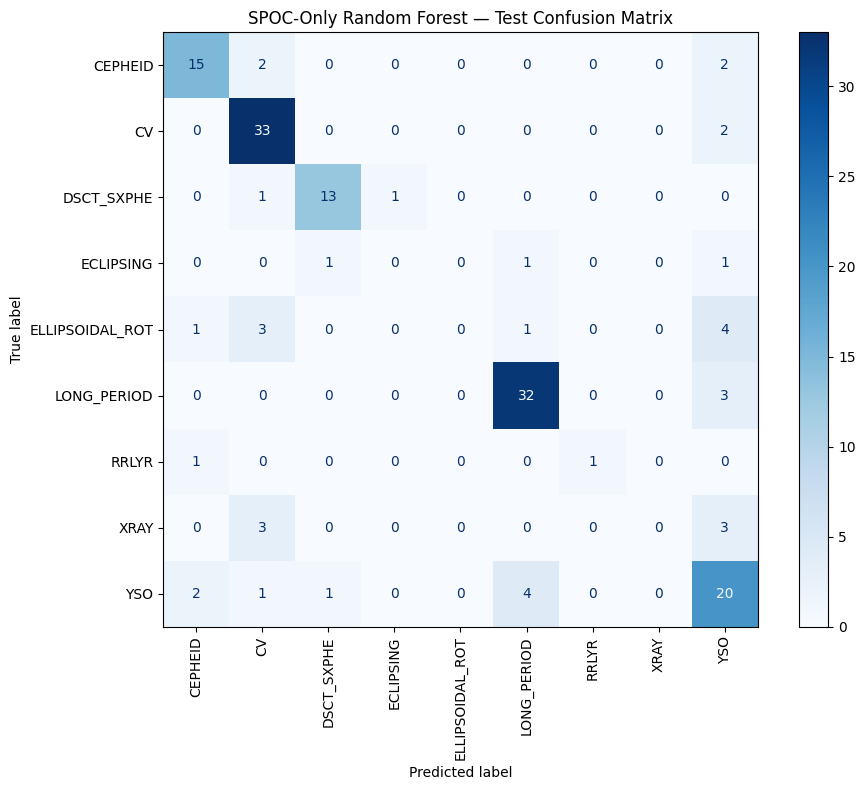

QLP-only Random Forest — test classification report:
                 precision    recall  f1-score   support

        CEPHEID       0.86      0.73      0.79        67
             CV       0.00      0.00      0.00         1
     DSCT_SXPHE       0.72      0.71      0.72        62
      ECLIPSING       0.82      0.42      0.56        33
ELLIPSOIDAL_ROT       0.47      0.60      0.52        45
    LONG_PERIOD       0.72      0.92      0.81       144
          RRLYR       1.00      0.50      0.67         4
           XRAY       0.00      0.00      0.00         3
            YSO       0.75      0.38      0.51        39

       accuracy                           0.71       398
      macro avg       0.59      0.47      0.51       398
   weighted avg       0.72      0.71      0.70       398



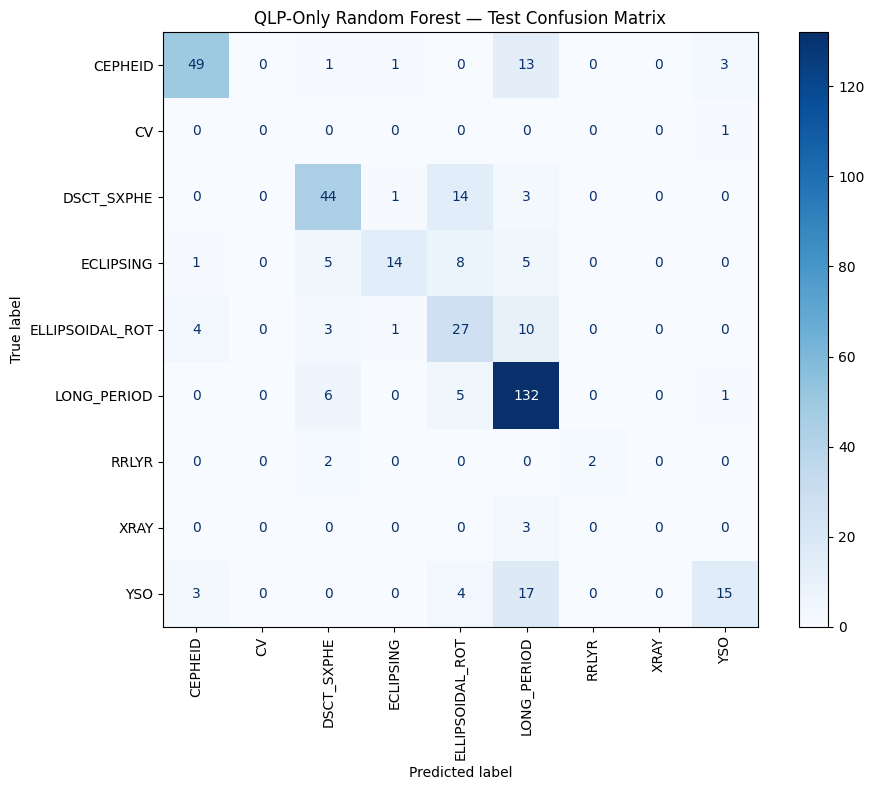

TESSCut-only Random Forest — test classification report:
                 precision    recall  f1-score   support

        CEPHEID       0.38      0.38      0.38       203
             CV       0.17      0.04      0.07       123
     DSCT_SXPHE       0.21      0.18      0.19       217
      ECLIPSING       0.20      0.24      0.22       250
ELLIPSOIDAL_ROT       0.28      0.33      0.30       241
    LONG_PERIOD       0.57      0.33      0.42       110
          RRLYR       0.20      0.28      0.24       270
           XRAY       0.00      0.00      0.00         6
            YSO       0.76      0.73      0.74       224

       accuracy                           0.33      1644
      macro avg       0.31      0.28      0.28      1644
   weighted avg       0.33      0.33      0.32      1644



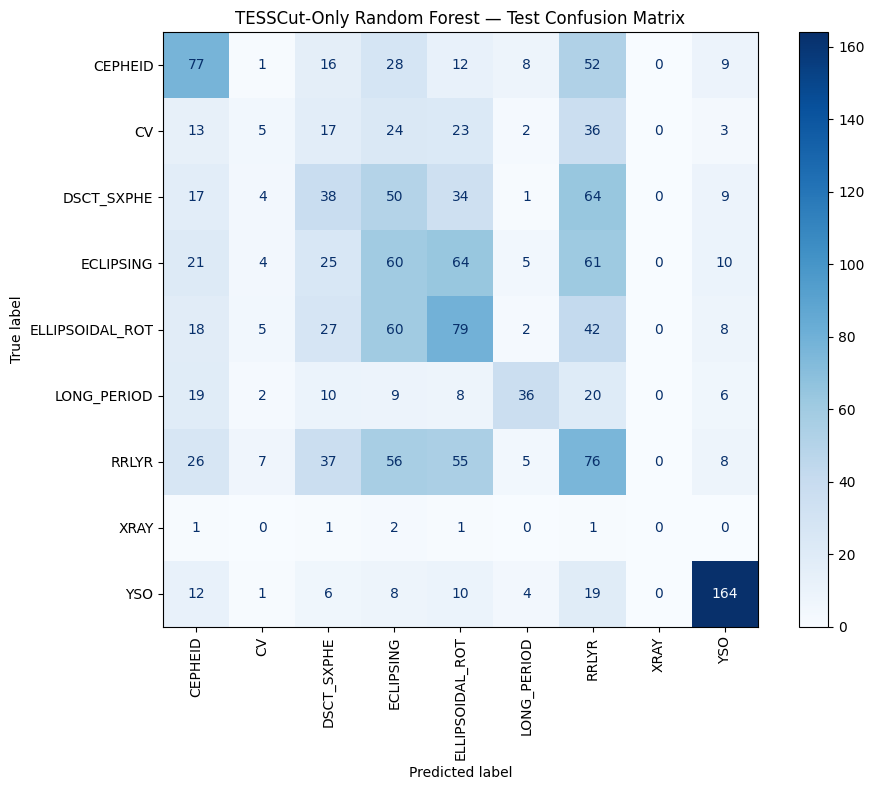

Per-family test metrics by provenance:


,Provenance,Family,Precision,Recall,F1Score,Support
0,SPOC,CEPHEID,0.789,0.789,0.789,19
1,SPOC,CV,0.767,0.943,0.846,35
2,SPOC,DSCT_SXPHE,0.867,0.867,0.867,15
3,SPOC,ECLIPSING,0.000,0.000,0.000,3
4,SPOC,ELLIPSOIDAL_ROT,0.000,0.000,0.000,9
5,SPOC,LONG_PERIOD,0.842,0.914,0.877,35
6,SPOC,RRLYR,1.000,0.500,0.667,2
7,SPOC,XRAY,0.000,0.000,0.000,6
8,SPOC,YSO,0.571,0.714,0.635,28
9,QLP,CEPHEID,0.860,0.731,0.790,67


In [29]:
# ============================================================
# Provenance-specific test confusion matrices
# ============================================================

from sklearn.metrics import ConfusionMatrixDisplay, classification_report

ProvenanceConfusionInputs = [
    ("SPOC", SpocResults["y_test"], SpocResults["test_pred"]),
    ("QLP", QlpResults["y_test"], QlpResults["test_pred"]),
    ("TESSCut", TessCutResults["y_test"], TessCutResults["test_pred"]),
]

ProvenanceClassificationReportRows = []

for ProvenanceName, yTrueProv, yPredProv in ProvenanceConfusionInputs:
    LabelsProv = sorted(pd.Series(yTrueProv).dropna().unique())

    print(f"{ProvenanceName}-only Random Forest — test classification report:")
    print(classification_report(
        yTrueProv,
        yPredProv,
        labels=LabelsProv,
        zero_division=0,
    ))

    Fig, Ax = plt.subplots(figsize=(10, 8))
    ConfusionMatrixDisplay.from_predictions(
        yTrueProv,
        yPredProv,
        labels=LabelsProv,
        xticks_rotation=90,
        cmap="Blues",
        values_format="d",
        ax=Ax,
    )
    Ax.set_title(f"{ProvenanceName}-Only Random Forest — Test Confusion Matrix")
    Fig.tight_layout()
    plt.show()
    plt.close(Fig)

    ReportDict = classification_report(
        yTrueProv,
        yPredProv,
        labels=LabelsProv,
        output_dict=True,
        zero_division=0,
    )

    for FamilyName in LabelsProv:
        FamilyMetrics = ReportDict.get(FamilyName, {})
        ProvenanceClassificationReportRows.append({
            "Provenance": ProvenanceName,
            "Family": FamilyName,
            "Precision": FamilyMetrics.get("precision", np.nan),
            "Recall": FamilyMetrics.get("recall", np.nan),
            "F1Score": FamilyMetrics.get("f1-score", np.nan),
            "Support": FamilyMetrics.get("support", np.nan),
        })

ProvenanceClassificationReportDf = pd.DataFrame(ProvenanceClassificationReportRows)

print("Per-family test metrics by provenance:")
display(
    ProvenanceClassificationReportDf.style.format({
        "Precision": "{:.3f}",
        "Recall": "{:.3f}",
        "F1Score": "{:.3f}",
        "Support": "{:.0f}",
    })
)

ProvenanceClassificationReportDf.to_csv(
    OutputDir / "provenance_specific_test_classification_metrics.csv",
    index=False,
)



### Feature Category Comparison

Individual feature rankings are useful, but they can be noisy because many features are correlated. A more interpretable comparison is to group features by their astrophysical meaning.

This section groups features into categories such as:

- periodicity / Lomb–Scargle structure
- phase-folded morphology
- amplitude
- flux distribution
- local variability / stochasticity
- observation quality / cadence

The goal is to compare *types of information* preserved by each provenance source rather than individual feature names alone.


In [30]:

# ============================================================
# Feature category importance comparison
# ============================================================

def categorize_feature(feature_name):
    """Map a feature name into a broad astrophysical/observational category."""
    f = str(feature_name)

    if f.startswith("Phase"):
        return "Phase-folded morphology"

    if f.startswith("Ls") or "Frequency" in f or "Period" in f or "FalseAlarm" in f:
        return "Periodicity / LS structure"

    if "Amplitude" in f:
        return "Amplitude / extrema"

    if (
        "Skewness" in f or
        "Kurtosis" in f or
        "Tail" in f or
        "P05" in f or
        "P10" in f or
        "P50" in f or
        "P90" in f or
        "P95" in f
    ):
        return "Flux distribution / shape"

    if (
        "EtaVonNeumann" in f or
        "SuccessiveDiff" in f or
        "MaxAbsSlope" in f or
        "Slope" in f or
        "Smoothness" in f
    ):
        return "Local variability / stochasticity"

    if (
        "Cadence" in f or
        "TimeSpan" in f or
        "Quality" in f or
        "Snr" in f or
        "SNR" in f or
        "LowSnr" in f
    ):
        return "Observation quality / cadence"

    if "FluxStd" in f or "Std" in f:
        return "Flux scatter / noise"

    return "Other"


CategoryRfImportanceDf = (
    ProvenanceFeatureImportanceDf
    .assign(Category=lambda df: df["Feature"].apply(categorize_feature))
    .groupby(["Provenance", "Category"], as_index=False)["RFImportance"]
    .sum()
    .sort_values(["Provenance", "RFImportance"], ascending=[True, False])
)

CategoryRfImportancePivotDf = (
    CategoryRfImportanceDf
    .pivot(index="Category", columns="Provenance", values="RFImportance")
    .fillna(0)
)

print("RF built-in importance by feature category:")
display(CategoryRfImportancePivotDf)


CategoryPermutationImportanceDf = (
    ProvenancePermutationImportanceDf
    .assign(Category=lambda df: df["Feature"].apply(categorize_feature))
    .groupby(["Provenance", "Category"], as_index=False)["PermutationImportanceMean"]
    .sum()
    .sort_values(["Provenance", "PermutationImportanceMean"], ascending=[True, False])
)

CategoryPermutationImportancePivotDf = (
    CategoryPermutationImportanceDf
    .pivot(index="Category", columns="Provenance", values="PermutationImportanceMean")
    .fillna(0)
)

print("Permutation importance by feature category:")
display(CategoryPermutationImportancePivotDf)


ProvenanceFeatureImportanceDf.to_csv(OutputDir / "provenance_rf_feature_importance.csv", index=False)
ProvenancePermutationImportanceDf.to_csv(OutputDir / "provenance_permutation_importance.csv", index=False)
CategoryRfImportancePivotDf.to_csv(OutputDir / "provenance_rf_feature_category_importance.csv")
CategoryPermutationImportancePivotDf.to_csv(OutputDir / "provenance_permutation_feature_category_importance.csv")

print("Saved provenance feature-importance comparison outputs to:")
print(OutputDir)


RF built-in importance by feature category:


Provenance,QLP,SPOC,TESSCut
Category,,,
Amplitude / extrema,0.028389,0.040663,0.052786
Flux distribution / shape,0.177749,0.126405,0.153838
Flux scatter / noise,0.055090,0.114597,0.071372
Local variability / stochasticity,0.057712,0.104315,0.089721
Observation quality / cadence,0.038005,0.039919,0.063558
Other,0.051503,0.069579,0.044060
Periodicity / LS structure,0.255042,0.255446,0.206412
Phase-folded morphology,0.336509,0.249077,0.318253


Permutation importance by feature category:


Provenance,QLP,SPOC,TESSCut
Category,,,
Amplitude / extrema,0.010181,-0.001587,0.002294
Flux distribution / shape,0.026943,0.013492,0.001442
Flux scatter / noise,0.012662,0.044179,-0.002622
Local variability / stochasticity,0.016580,0.023187,-0.002083
Observation quality / cadence,0.012281,0.004921,-0.001647
Other,0.004601,0.000384,0.000815
Periodicity / LS structure,0.003919,0.020514,-0.018269
Phase-folded morphology,0.061107,0.014532,-0.024488


Saved provenance feature-importance comparison outputs to:
/data/projects/TESS-research/ml_analytics/output



### Provenance-Specific Feature Importance Interpretation

This analysis should be interpreted together with the provenance-specific accuracy results.

If the top features and feature-category totals differ substantially across SPOC, QLP, and TESSCut models, that supports the idea that provenance does not merely change overall noise level. Instead, different preprocessing and extraction pipelines may change which categories of astrophysical information remain recoverable.

A scientifically meaningful pattern would be:

| Provenance Pattern | Interpretation |
|---|---|
| SPOC relies more on periodic / harmonic features | cleaner pipeline products preserve detailed periodic structure |
| QLP relies on mixed periodic and statistical features | intermediate preprocessing preserves some periodic information but less consistently |
| TESSCut relies more on amplitude, slope, cadence, or flux-distribution features | cutout-based light curves may retain coarse variability but weaken fine harmonic separability |
| Phase-folded morphology features rank highly across models | folded light-curve shape contains real astrophysical information |
| Observation-quality features rank highly | model performance is partly limited by data quality and sampling effects |

Important caution: provenance-specific datasets differ not only in preprocessing pipeline, but also in sample size and class distribution. Therefore, feature-importance differences should be interpreted as evidence of **provenance-associated information shifts**, not as a perfectly isolated causal effect of the pipeline alone.

Overall, this section helps connect the machine-learning results to the central astrophysical question:

> How do different TESS light-curve provenance sources affect the recoverability of variable-star signatures?



## Step 20 — Provenance-Specific Feature Importance Interpretation and SPOC Diagnostic Follow-Up

### Confirmation of Provenance-Specific Feature Importance Result

The Step 18 provenance-specific feature-importance comparison supports one of the central conclusions of the project:

> Different TESS light-curve provenance sources preserve different categories of astrophysical variability information, causing Random Forest classifiers to rely on substantially different feature groups for variable-star classification.

This conclusion is stronger than a simple accuracy comparison. Accuracy shows that SPOC, QLP, and TESSCut perform differently; feature importance helps explain *why* they perform differently.

---

### SPOC-only Model

The SPOC-only model relies strongly on:

- `OriginalFluxStd`
- `OriginalFluxSnr`
- Lomb–Scargle period and frequency features
- harmonic structure features
- some phase morphology features

This suggests that SPOC light curves preserve high-quality variability information and detailed periodic/harmonic structure that remain useful for classification.

---

### QLP-only Model

The QLP-only model shows a more mixed pattern, using:

- local variability features
- phase-morphology features
- signal-to-noise / flux-scatter features
- selected LS period features
- observation-baseline features such as `TimeSpanDays`

This suggests that QLP preserves some periodic structure, but the model relies more on a mixture of morphology, local variability, and signal-quality descriptors than in the SPOC-only case.

---

### TESSCut-only Model

The TESSCut-only model relies more heavily on:

- `TimeSpanDays`
- `CadenceCount`
- `EtaVonNeumann`
- `FluxAmplitude`
- robust flux-distribution and tail features
- `MaxAbsSlope`
- `FluxSkewness`
- `FluxKurtosis`

Detailed LS/harmonic features are less dominant. This suggests that TESSCut classification depends more on coarse statistical variability, cadence, slope, and flux-distribution descriptors rather than clean periodic/harmonic structure.

---

### Scientific Interpretation

The Step 18 results suggest that provenance affects not only the overall classification accuracy, but also the type of astrophysical information available to the classifier.

| Provenance | Dominant Information Used by RF |
|---|---|
| SPOC | flux scatter/SNR plus periodic and harmonic structure |
| QLP | mixed local variability, morphology, SNR, and some periodic structure |
| TESSCut | cadence, amplitude, slope, stochasticity, and flux-distribution descriptors |

This supports the project’s broader scientific interpretation:

> Different light-curve provenance sources are associated with different recoverable astrophysical variability signatures.

---

### Important Caution

The safest wording is not that provenance alone causally determines feature importance. The provenance-specific subsets also differ in:

- sample size
- class distribution
- observational availability
- preprocessing pipeline
- possible TESSCut source-association uncertainty

Therefore, the most defensible conclusion is:

> The observed provenance-specific datasets exhibit substantially different feature-importance patterns, consistent with the interpretation that different light-curve products preserve different categories of astrophysical variability information.

---

### Unexpected Observation: `OriginalFluxStd` and `OriginalFluxSnr`

One unexpected result is that `OriginalFluxStd` and `OriginalFluxSnr` ranked very highly for the SPOC-only model.

This deserves follow-up because these features may represent:

1. real astrophysical variability strength,
2. data quality / noise behavior,
3. class-distribution effects,
4. or a combination of astrophysical and observational information.

The diagnostic code below investigates whether these two features differ strongly by class, correlate with amplitude or quality features, or are associated with correct versus incorrect SPOC predictions.


In [31]:

# ============================================================
# Step 19 Diagnostic: OriginalFluxStd and OriginalFluxSnr in SPOC
# ============================================================

DiagnosticFeatures = [
    col for col in ["OriginalFluxStd", "OriginalFluxSnr"]
    if col in globals().get("ProvenanceComparisonDfForTraining", ModelDf).columns
]

if len(DiagnosticFeatures) == 0:
    raise KeyError(
        "Neither OriginalFluxStd nor OriginalFluxSnr exists in the current dataframe."
    )

# Use the final dataframe from Step 18 if available; otherwise fall back to ModelDf.
DiagnosticBaseDf = globals().get("ProvenanceComparisonDfForTraining", ModelDf).copy()

# Identify provenance column robustly.
PossibleProvenanceColumns = ["Provenance", "provenance", "Source", "source"]
DiagnosticProvenanceColumn = None

for CandidateColumn in PossibleProvenanceColumns:
    if CandidateColumn in DiagnosticBaseDf.columns:
        DiagnosticProvenanceColumn = CandidateColumn
        break

if DiagnosticProvenanceColumn is None:
    raise KeyError(
        "Could not find provenance/source column. "
        f"Tried: {PossibleProvenanceColumns}"
    )

SpocDiagnosticDf = DiagnosticBaseDf[
    DiagnosticBaseDf[DiagnosticProvenanceColumn] == "SPOC"
].copy()

print(f"SPOC diagnostic row count: {len(SpocDiagnosticDf)}")
print(f"Using provenance column: {DiagnosticProvenanceColumn}")
print(f"Diagnostic features available: {DiagnosticFeatures}")


# ------------------------------------------------------------
# 1. Distribution of OriginalFluxStd / OriginalFluxSnr by class
# ------------------------------------------------------------

SpocFeatureByClassDf = (
    SpocDiagnosticDf
    .groupby(TargetColumn)[DiagnosticFeatures]
    .agg(["count", "mean", "median", "std"])
)

print("OriginalFluxStd / OriginalFluxSnr by class within SPOC:")
display(SpocFeatureByClassDf)


# ------------------------------------------------------------
# 2. Correct-vs-incorrect diagnostic if SPOC model variables exist
# ------------------------------------------------------------

RequiredSpocObjects = ["SpocRfModel", "XSpocTest", "YSpocTest"]
MissingSpocObjects = [name for name in RequiredSpocObjects if name not in globals()]

if MissingSpocObjects:
    print(
        "Skipping correct-vs-incorrect SPOC prediction diagnostic because "
        f"these objects are missing: {MissingSpocObjects}"
    )
else:
    SpocTestPredictionDf = XSpocTest.copy()
    SpocTestPredictionDf[TargetColumn] = YSpocTest
    SpocTestPredictionDf["Prediction"] = SpocRfModel.predict(XSpocTest)
    SpocTestPredictionDf["Correct"] = (
        SpocTestPredictionDf[TargetColumn] == SpocTestPredictionDf["Prediction"]
    )

    CorrectComparisonFeatures = [
        col for col in DiagnosticFeatures
        if col in SpocTestPredictionDf.columns
    ]

    if CorrectComparisonFeatures:
        SpocCorrectVsIncorrectDf = (
            SpocTestPredictionDf
            .groupby("Correct")[CorrectComparisonFeatures]
            .agg(["count", "mean", "median", "std"])
        )

        print("SPOC test set: OriginalFluxStd / OriginalFluxSnr for correct vs incorrect predictions:")
        display(SpocCorrectVsIncorrectDf)
    else:
        print("Diagnostic features are not present in XSpocTest; skipping correct-vs-incorrect comparison.")


# ------------------------------------------------------------
# 3. Correlation with related amplitude / quality / variability features
# ------------------------------------------------------------

CandidateCorrelationFeatures = [
    "OriginalFluxStd",
    "OriginalFluxSnr",
    "FluxAmplitude",
    "FluxPercentAmplitude95To5",
    "PhaseAmplitude95To5",
    "EtaVonNeumann",
    "MedianAbsSuccessiveDiff",
    "LsMaxPower",
    "LsFalseAlarmProbability",
    "LsLogFalseAlarmProbability",
    "CadenceCount",
    "TimeSpanDays",
]

AvailableCorrelationFeatures = [
    col for col in CandidateCorrelationFeatures
    if col in SpocDiagnosticDf.columns
]

if len(AvailableCorrelationFeatures) >= 2:
    SpocCorrelationDf = SpocDiagnosticDf[AvailableCorrelationFeatures].corr(
        method="spearman"
    )

    print("Spearman correlation among SPOC diagnostic / variability / quality features:")
    display(SpocCorrelationDf)

    ImportantCorrelationRows = [
        col for col in ["OriginalFluxStd", "OriginalFluxSnr"]
        if col in SpocCorrelationDf.index
    ]

    if ImportantCorrelationRows:
        print("Correlations involving OriginalFluxStd / OriginalFluxSnr:")
        display(
            SpocCorrelationDf
            .loc[ImportantCorrelationRows]
            .T
            .sort_values(ImportantCorrelationRows[0], ascending=False)
        )
else:
    print("Not enough related features available for correlation analysis.")


# ------------------------------------------------------------
# 4. Class-level median diagnostic features and sample counts
# ------------------------------------------------------------

SpocClassSupportDf = (
    SpocDiagnosticDf[TargetColumn]
    .value_counts()
    .rename_axis(TargetColumn)
    .reset_index(name="SpocSampleCount")
)

SpocClassFeatureSummaryDf = (
    SpocDiagnosticDf
    .groupby(TargetColumn)[DiagnosticFeatures]
    .median()
    .reset_index()
    .merge(SpocClassSupportDf, on=TargetColumn, how="left")
    .sort_values("SpocSampleCount", ascending=False)
)

print("SPOC class-level median diagnostic features and sample count:")
display(SpocClassFeatureSummaryDf)


SPOC diagnostic row count: 505
Using provenance column: Provenance
Diagnostic features available: ['OriginalFluxStd', 'OriginalFluxSnr']
OriginalFluxStd / OriginalFluxSnr by class within SPOC:


OriginalFluxStd                               OriginalFluxSnr                                    
                          count      mean    median       std           count        mean      median         std
family                                                                                                           
CEPHEID                      62  0.160163  0.115152  0.139279              62    9.448759    8.684484    5.743126
CV                          117  2.508760  1.038122  3.332422             117    2.725942    0.963278    6.523727
DSCT_SXPHE                   51  0.034900  0.004409  0.102196              51  359.767264  226.787631  454.587513
ECLIPSING                    11  0.061661  0.052908  0.031471              11   22.115634   18.900585   16.337702
ELLIPSOIDAL_ROT              29  0.016846  0.007028  0.024907              29  230.632152  142.290168  245.157974
LONG_PERIOD                 116  0.009684  0.006865  0.010999             116  265.702140  145.669910  321.509548
RRLYR                         5  0.139091  0.104370  0.061278               5    8.233980    9.581260    3.010721
XRAY                         20  1.384162  0.119527  2.213825              20  212.366208   15.009396  587.537013
YSO                          94  0.154511  0.069745  0.299179              94   44.434194   14.340045   84.238184

SPOC test set: OriginalFluxStd / OriginalFluxSnr for correct vs incorrect predictions:


OriginalFluxStd                              
                  count      mean    median       std
Correct                                              
False                38  0.295369  0.033459  1.193450
True                114  0.751792  0.078337  2.176386

Spearman correlation among SPOC diagnostic / variability / quality features:


,OriginalFluxStd,OriginalFluxSnr,FluxAmplitude,FluxPercentAmplitude95To5,PhaseAmplitude95To5,EtaVonNeumann,MedianAbsSuccessiveDiff,LsMaxPower,LsFalseAlarmProbability,LsLogFalseAlarmProbability,CadenceCount,TimeSpanDays
OriginalFluxStd,1.000000,-1.000000,0.033895,0.037528,-0.354522,0.371752,0.396582,-0.292782,0.419059,0.419059,-0.115278,-0.343091
OriginalFluxSnr,-1.000000,1.000000,-0.033895,-0.037528,0.354522,-0.371752,-0.396582,0.292782,-0.419059,-0.419059,0.115278,0.343091
FluxAmplitude,0.033895,-0.033895,1.000000,-0.105345,-0.471835,0.570375,0.444810,-0.639369,0.202935,0.202935,0.439853,0.255229
FluxPercentAmplitude95To5,0.037528,-0.037528,-0.105345,1.000000,-0.103234,0.124035,0.142335,-0.203767,0.169439,0.169439,-0.010772,-0.008076
PhaseAmplitude95To5,-0.354522,0.354522,-0.471835,-0.103234,1.000000,-0.733239,-0.748302,0.796222,-0.673057,-0.673057,-0.108429,0.119907
EtaVonNeumann,0.371752,-0.371752,0.570375,0.124035,-0.733239,1.000000,0.933972,-0.786493,0.674877,0.674877,0.046637,-0.181348
MedianAbsSuccessiveDiff,0.396582,-0.396582,0.444810,0.142335,-0.748302,0.933972,1.000000,-0.726713,0.675848,0.675848,-0.102107,-0.317788
LsMaxPower,-0.292782,0.292782,-0.639369,-0.203767,0.796222,-0.786493,-0.726713,1.000000,-0.716758,-0.716758,-0.153395,0.031933
LsFalseAlarmProbability,0.419059,-0.419059,0.202935,0.169439,-0.673057,0.674877,0.675848,-0.716758,1.000000,1.000000,-0.210809,-0.244446
LsLogFalseAlarmProbability,0.419059,-0.419059,0.202935,0.169439,-0.673057,0.674877,0.675848,-0.716758,1.000000,1.000000,-0.210809,-0.244446


Correlations involving OriginalFluxStd / OriginalFluxSnr:


,OriginalFluxStd,OriginalFluxSnr
OriginalFluxStd,1.000000,-1.000000
LsLogFalseAlarmProbability,0.419059,-0.419059
LsFalseAlarmProbability,0.419059,-0.419059
MedianAbsSuccessiveDiff,0.396582,-0.396582
EtaVonNeumann,0.371752,-0.371752
FluxPercentAmplitude95To5,0.037528,-0.037528
FluxAmplitude,0.033895,-0.033895
CadenceCount,-0.115278,0.115278
LsMaxPower,-0.292782,0.292782
TimeSpanDays,-0.343091,0.343091


SPOC class-level median diagnostic features and sample count:


,family,OriginalFluxStd,OriginalFluxSnr,SpocSampleCount
1,CV,1.038122,0.963278,117
5,LONG_PERIOD,0.006865,145.669910,116
8,YSO,0.069745,14.340045,94
0,CEPHEID,0.115152,8.684484,62
2,DSCT_SXPHE,0.004409,226.787631,51
4,ELLIPSOIDAL_ROT,0.007028,142.290168,29
7,XRAY,0.119527,15.009396,20
3,ECLIPSING,0.052908,18.900585,11
6,RRLYR,0.104370,9.581260,5



### Interpretation Guide for the SPOC `OriginalFluxStd` / `OriginalFluxSnr` Diagnostic

Use the diagnostic outputs as follows:

- If `OriginalFluxStd` and `OriginalFluxSnr` differ strongly by variable-star family, they likely encode real astrophysical variability strength.
- If they are strongly associated with correct predictions, they may help identify high-quality or high-amplitude cases that are easier to classify.
- If they correlate strongly with amplitude features, they are probably acting partly as astrophysical variability-amplitude proxies.
- If they correlate strongly with quality/cadence features, they may also reflect observational quality or sampling effects.
- If they are dominated by a few high-support classes, their importance may partly reflect class distribution.

The most scientifically careful interpretation is that `OriginalFluxStd` and `OriginalFluxSnr` likely combine astrophysical and observational information. They should therefore be discussed as informative variability/quality descriptors, rather than as purely physical stellar parameters.



### Update: Origin of `OriginalFluxStd` and `OriginalFluxSnr`

The high importance of `OriginalFluxStd` and `OriginalFluxSnr` in the SPOC-only model motivated a follow-up check of the upstream feature-generation logic.

The origin of these fields was traced to `tess_variable_star_categorization.ipynb`, where the relevant quantities are computed as:

```python
medianFlux = float(np.nanmedian(validFlux))
stdFlux = float(np.nanstd(validFlux))

fluxSnr = None if lowStd else float(abs(medianFlux) / stdFlux)
```

Therefore:

```text
fluxSnr = abs(fluxMedian) / fluxStd
```

This explains why `OriginalFluxStd` and `OriginalFluxSnr` show an almost perfect Spearman anti-correlation.

They are not independent features. Instead, `OriginalFluxSnr` is mathematically derived from `fluxStd` and the median flux level. If the median flux is relatively stable or normalized across a subset of light curves, then increasing `fluxStd` will almost automatically decrease `fluxSnr`.

---

### Revised Interpretation

The earlier diagnostic showed that `OriginalFluxStd` and `OriginalFluxSnr` vary substantially across variable-star families and are important for the SPOC-only Random Forest model. However, because `OriginalFluxSnr` is derived from `OriginalFluxStd`, they should not be interpreted as two independent astrophysical discoveries.

A more careful interpretation is:

> `OriginalFluxStd` and `OriginalFluxSnr` form a linked variability / signal-quality descriptor group. Their high feature importance in the SPOC-only model likely reflects the importance of flux scatter relative to baseline signal level, rather than two independent physical measurements.

This does not invalidate the SPOC feature-importance result. Instead, it clarifies that the model is strongly using a single underlying concept:

```text
relative flux scatter / variability strength
```

rather than two unrelated quantities.

---

### Scientific Meaning

In well-processed SPOC light curves, relative flux scatter can still be astrophysically meaningful because different variable-star families naturally exhibit different variability amplitudes, smoothness, and scatter properties.

However, because this descriptor also depends on measurement noise and preprocessing, it should be described cautiously as a combined astrophysical-and-observational feature.

The safest wording for the paper/notebook is:

> The SPOC-only model assigns high importance to a linked flux-scatter / signal-to-noise descriptor group (`OriginalFluxStd`, `OriginalFluxSnr`). Since `fluxSnr` is defined as `abs(fluxMedian) / fluxStd`, these features are mathematically related and should be interpreted together rather than as independent predictors. Their importance suggests that relative flux scatter is a major discriminative signal in the SPOC subset, likely combining intrinsic variability strength with observational noise behavior.

---

### Implication for Feature Importance Analysis

Because `OriginalFluxStd` and `OriginalFluxSnr` are highly redundant, future feature-importance interpretation should avoid double-counting them.

For scientific discussion, they should be grouped under a single category such as:

```text
Flux scatter / relative signal strength
```

rather than discussed separately.

This reinforces the broader conclusion that feature importance must be interpreted with awareness of feature definitions and correlations, not only model rankings.



### Final Update: Effect of `OriginalFluxStd` / `OriginalFluxSnr` Redundancy on the Provenance Conclusion

The discovery that `OriginalFluxSnr` is computed from `OriginalFluxStd` changes how these two features should be interpreted, but it does **not** weaken the main provenance conclusion.

Because:

```text
fluxSnr = abs(fluxMedian) / fluxStd
```

the two features are mathematically related. Therefore, they should not be interpreted as two independent predictors.

Instead, they should be treated as a single linked feature group:

```text
Flux scatter / relative signal-strength descriptor
```

This descriptor likely combines:

- intrinsic variability strength,
- light-curve scatter,
- baseline flux level,
- and observational noise behavior.

---

### Revised SPOC Interpretation

The earlier statement:

> The SPOC-only model ranked `OriginalFluxStd` and `OriginalFluxSnr` as the two most important features.

should be interpreted more carefully as:

> The SPOC-only model assigns high importance to a linked flux-scatter / relative signal-strength descriptor group (`OriginalFluxStd`, `OriginalFluxSnr`), together with Lomb–Scargle period and harmonic features.

This is more scientifically accurate because `OriginalFluxStd` and `OriginalFluxSnr` are not independent measurements.

---

### Does This Affect the Provenance Feature-Importance Conclusion?

No. The main conclusion remains strongly supported.

The provenance-specific models still rely on clearly different feature groups:

| Provenance | Dominant Information Used by RF |
|---|---|
| SPOC | linked flux-scatter / relative signal-strength features plus periodic and harmonic structure |
| QLP | mixed local variability, morphology, SNR/scatter, and selected periodic structure |
| TESSCut | cadence, amplitude, slope, stochasticity, and flux-distribution descriptors |

The important result is not that two separate SPOC features ranked highly. The important result is that the **overall feature-importance pattern differs substantially across provenance-specific models**.

In particular:

- SPOC uses flux-scatter / signal-strength information together with LS period and harmonic structure.
- QLP uses a mixed feature set involving local variability, morphology, signal strength, and some periodicity.
- TESSCut relies much more strongly on cadence, amplitude, slope, stochasticity, and broad flux-distribution statistics.

Therefore, the redundancy between `OriginalFluxStd` and `OriginalFluxSnr` does not invalidate the provenance conclusion. It only improves the precision of the interpretation.

---

### Final Provenance Feature-Importance Claim

The most scientifically defensible conclusion is:

> The observed provenance-specific datasets exhibit substantially different feature-importance patterns. These differences are consistent with the interpretation that different TESS light-curve products preserve different categories of recoverable astrophysical variability information.

This wording is strong but appropriately cautious.

It avoids overclaiming that provenance alone is the sole cause, because class distribution, sample size, source association uncertainty, and extraction differences may also contribute. However, the combined accuracy, confusion-matrix, and feature-importance evidence still strongly supports the conclusion that provenance is a major factor shaping Random Forest classification behavior.
